In [480]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tbats import TBATS
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsforecast import StatsForecast
from statsforecast.models import AutoTBATS
import warnings
warnings.filterwarnings('ignore')
import re

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("Librerías importadas correctamente")

NumPy version: 2.4.6
Pandas version: 2.3.3
Librerías importadas correctamente


In [481]:
ruta_excel_matriz = "./Datos/df_matriz_ventas_articulos_forecast.xlsx"
df=pd.read_excel(ruta_excel_matriz)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   codigo_articulo           450 non-null    object 
 1   descripcion_completa      449 non-null    object 
 2   grupo_articulo            450 non-null    object 
 3   categoria                 411 non-null    object 
 4   subcategoria              411 non-null    object 
 5   tipo                      406 non-null    object 
 6   marca_fabricante          450 non-null    object 
 7   unidad_medida_inventario  450 non-null    object 
 8   cluster_kmeans_final      448 non-null    float64
 9   descripcion_cluster       448 non-null    object 
 10  venta_2024_01             450 non-null    float64
 11  venta_2024_02             450 non-null    float64
 12  venta_2024_03             450 non-null    float64
 13  venta_2024_04             450 non-null    float64
 14  venta_2024

In [482]:
df.head()

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,cluster_kmeans_final,descripcion_cluster,...,venta_2025_10,venta_2025_11,venta_2025_12,venta_2026_01,venta_2026_02,venta_2026_03,venta_2026_04,venta_2026_05,venta_2026_06,venta_2026_07
0,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",...,6.0,12.0,0.0,0.0,24.0,0.0,0.0,24.0,9.0,0.0
1,0270H,"Manga de sincronismo, 270H, longitud externa 2...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,2.0,Demanda activa y reciente con señales de creci...,...,50.0,600.0,225.0,150.0,38.0,200.0,19.0,0.0,300.0,350.0
2,0384-3M-JASON,"Manga de sincronismo, 384-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,15.0,30.0,55.0,45.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0390H-JASON,"Manga de sincronismo, 390H, longitud externa 3...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,JASON,MM,2.0,Demanda activa y reciente con señales de creci...,...,0.0,0.0,0.0,0.0,25.0,0.0,201.0,25.0,140.0,0.0
4,0420H,"Manga de sincronismo, 420H, longitud externa 4...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,38.0,0.0,0.0,50.0,0.0,0.0,19.0,0.0,0.0,0.0


In [483]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   codigo_articulo           450 non-null    object 
 1   descripcion_completa      449 non-null    object 
 2   grupo_articulo            450 non-null    object 
 3   categoria                 411 non-null    object 
 4   subcategoria              411 non-null    object 
 5   tipo                      406 non-null    object 
 6   marca_fabricante          450 non-null    object 
 7   unidad_medida_inventario  450 non-null    object 
 8   cluster_kmeans_final      448 non-null    float64
 9   descripcion_cluster       448 non-null    object 
 10  venta_2024_01             450 non-null    float64
 11  venta_2024_02             450 non-null    float64
 12  venta_2024_03             450 non-null    float64
 13  venta_2024_04             450 non-null    float64
 14  venta_2024

In [484]:
lista_columnas_numericas = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
print(f"Columnas numéricas del DataFrame: {lista_columnas_numericas}")
print(f" longitud de la lista de columnas numéricas: {len(lista_columnas_numericas)}")
lista_col_ventas = [col for col in df.columns if col.startswith('venta_')]
print(f"Columnas de ventas del DataFrame: {lista_col_ventas}")


Columnas numéricas del DataFrame: ['cluster_kmeans_final', 'venta_2024_01', 'venta_2024_02', 'venta_2024_03', 'venta_2024_04', 'venta_2024_05', 'venta_2024_06', 'venta_2024_07', 'venta_2024_08', 'venta_2024_09', 'venta_2024_10', 'venta_2024_11', 'venta_2024_12', 'venta_2025_01', 'venta_2025_02', 'venta_2025_03', 'venta_2025_04', 'venta_2025_05', 'venta_2025_06', 'venta_2025_07', 'venta_2025_08', 'venta_2025_09', 'venta_2025_10', 'venta_2025_11', 'venta_2025_12', 'venta_2026_01', 'venta_2026_02', 'venta_2026_03', 'venta_2026_04', 'venta_2026_05', 'venta_2026_06', 'venta_2026_07']
 longitud de la lista de columnas numéricas: 32
Columnas de ventas del DataFrame: ['venta_2024_01', 'venta_2024_02', 'venta_2024_03', 'venta_2024_04', 'venta_2024_05', 'venta_2024_06', 'venta_2024_07', 'venta_2024_08', 'venta_2024_09', 'venta_2024_10', 'venta_2024_11', 'venta_2024_12', 'venta_2025_01', 'venta_2025_02', 'venta_2025_03', 'venta_2025_04', 'venta_2025_05', 'venta_2025_06', 'venta_2025_07', 'venta_2

In [495]:
df_ventas=df[lista_col_ventas + ["codigo_articulo"]]
df_ventas.set_index("codigo_articulo", inplace=True)
df_ventas.head(10)

,venta_2024_01,venta_2024_02,venta_2024_03,venta_2024_04,venta_2024_05,venta_2024_06,venta_2024_07,venta_2024_08,venta_2024_09,venta_2024_10,...,venta_2025_10,venta_2025_11,venta_2025_12,venta_2026_01,venta_2026_02,venta_2026_03,venta_2026_04,venta_2026_05,venta_2026_06,venta_2026_07
codigo_articulo,,,,,,,,,,,,,,,,,,,,,
0225-3M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0.0,0.0,...,6.0,12.0,0.0,0.0,24.0,0.0,0.0,24.0,9.0,0.0
0270H,0.0,0.0,0.0,0.0,10.0,0.0,482.0,0.0,10.0,0.0,...,50.0,600.0,225.0,150.0,38.0,200.0,19.0,0.0,300.0,350.0
0384-3M-JASON,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.0,30.0,55.0,45.0,0.0,0.0,0.0,0.0,0.0,0.0
0390H-JASON,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,25.0,0.0,201.0,25.0,140.0,0.0
0420H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,0.0,...,38.0,0.0,0.0,50.0,0.0,0.0,19.0,0.0,0.0,0.0
0475-5M,0.0,0.0,0.0,0.0,30.0,0.0,95.0,85.0,0.0,0.0,...,180.0,30.0,0.0,0.0,0.0,0.0,580.0,0.0,0.0,0.0
0475-5M-JASON,0.0,100.0,75.0,30.0,30.0,0.0,30.0,0.0,0.0,0.0,...,150.0,0.0,30.0,0.0,0.0,0.0,22.0,0.0,20.0,0.0
0480-3M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0,20.0,...,0.0,0.0,0.0,80.0,11.0,80.0,0.0,0.0,0.0,0.0
0510H-JASON,164.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0.0,...,0.0,76.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# ============================================================
# 1. Detectar columnas mensuales de venta
# ============================================================

def obtener_columnas_venta_ordenadas(df):
    """
    Detecta columnas tipo venta_YYYY_MM las convierte a datetime (format="%Y_%m_%d") y las ordena cronológicamente.
    """

    patron = r"^venta_\d{4}_\d{2}$"

    columnas_venta = [
        col for col in df.columns
        if re.match(patron, str(col))
    ]

    columnas_venta = sorted(
        columnas_venta,
        key=lambda col: pd.to_datetime(
            col.replace("venta_", "") + "_01",
            format="%Y_%m_%d"
        )
    )

    return columnas_venta


def columna_venta_a_fecha(columna):
    """
    Convierte una columna tipo venta_2024_01 a fecha fin de mes.
    """

    fecha = pd.to_datetime(
        columna.replace("venta_", "") + "_01",
        format="%Y_%m_%d"
    ) + pd.offsets.MonthEnd(0)

    return fecha

In [ ]:
# df_ventas=obtener_columnas_venta_ordenadas(df)
# columna = "venta_2026_08"
# prueba=columna_venta_a_fecha(columna)
# print(prueba)

2026-08-31 00:00:00


In [399]:
columnas_venta = obtener_columnas_venta_ordenadas(df_ventas)

print("Cantidad de columnas de venta:")
print(len(columnas_venta))

print("Primera columna:")
print(columnas_venta[0])

print("Última columna:")
print(columnas_venta[-1])

Cantidad de columnas de venta:
31
Primera columna:
venta_2024_01
Última columna:
venta_2026_07


In [400]:

# 2. Convertir matriz mensual a formato largo
# ============================================================

def convertir_matriz_a_formato_largo(df_ventas, columnas_venta):
    """
    Convierte la matriz mensual por artículo a formato largo:
    codigo_articulo | columna_venta | fecha_mes | venta_mensual
    """

    df_temp = df_ventas.copy()


    if "codigo_articulo" not in df_temp.columns:
        df_temp = df_temp.reset_index()

    columnas_id = [
        col for col in df_temp.columns
        if col not in columnas_venta
    ]
    #Si best_model columna esta presente incluirla


    df_long = df_temp.melt(
        id_vars=columnas_id,
        value_vars=columnas_venta,
        var_name="columna_venta",
        value_name="venta_mensual"
    )

    df_long["fecha_mes"] = df_long["columna_venta"].apply(
        columna_venta_a_fecha
    )

    df_long["venta_mensual"] = pd.to_numeric(
        df_long["venta_mensual"],
        errors="coerce"
    ).fillna(0)

   

    df_long = df_long.sort_values(
        by=["codigo_articulo", "fecha_mes"]
    ).reset_index(drop=True)

    return df_long

In [401]:
df_series_long = convertir_matriz_a_formato_largo(
    df_ventas=df_ventas,
    columnas_venta=columnas_venta
)

df_series_long.head(31)

,codigo_articulo,columna_venta,venta_mensual,fecha_mes
0,0225-3M,venta_2024_01,0.0,2024-01-31
1,0225-3M,venta_2024_02,0.0,2024-02-29
2,0225-3M,venta_2024_03,0.0,2024-03-31
3,0225-3M,venta_2024_04,0.0,2024-04-30
4,0225-3M,venta_2024_05,0.0,2024-05-31
5,0225-3M,venta_2024_06,0.0,2024-06-30
6,0225-3M,venta_2024_07,0.0,2024-07-31
7,0225-3M,venta_2024_08,18.0,2024-08-31
8,0225-3M,venta_2024_09,0.0,2024-09-30
9,0225-3M,venta_2024_10,0.0,2024-10-31


In [402]:
df_series_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13950 entries, 0 to 13949
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   codigo_articulo  13950 non-null  object        
 1   columna_venta    13950 non-null  object        
 2   venta_mensual    13950 non-null  float64       
 3   fecha_mes        13950 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 436.1+ KB


In [403]:
df_codigo_ejemplo=df_series_long[df_series_long["codigo_articulo"] == "UCM36LPSS12"]
df_codigo_ejemplo=df_codigo_ejemplo.sort_values(by="fecha_mes").reset_index(drop=True).copy()
df_codigo_ejemplo

,codigo_articulo,columna_venta,venta_mensual,fecha_mes
0,UCM36LPSS12,venta_2024_01,0.0,2024-01-31
1,UCM36LPSS12,venta_2024_02,0.0,2024-02-29
2,UCM36LPSS12,venta_2024_03,4.0,2024-03-31
3,UCM36LPSS12,venta_2024_04,6.0,2024-04-30
4,UCM36LPSS12,venta_2024_05,7.0,2024-05-31
5,UCM36LPSS12,venta_2024_06,0.0,2024-06-30
6,UCM36LPSS12,venta_2024_07,0.0,2024-07-31
7,UCM36LPSS12,venta_2024_08,0.0,2024-08-31
8,UCM36LPSS12,venta_2024_09,4.0,2024-09-30
9,UCM36LPSS12,venta_2024_10,1.0,2024-10-31


Entrenamiento: 24 observaciones (0 a 23)
Prueba: 7 observaciones (24 a 30)


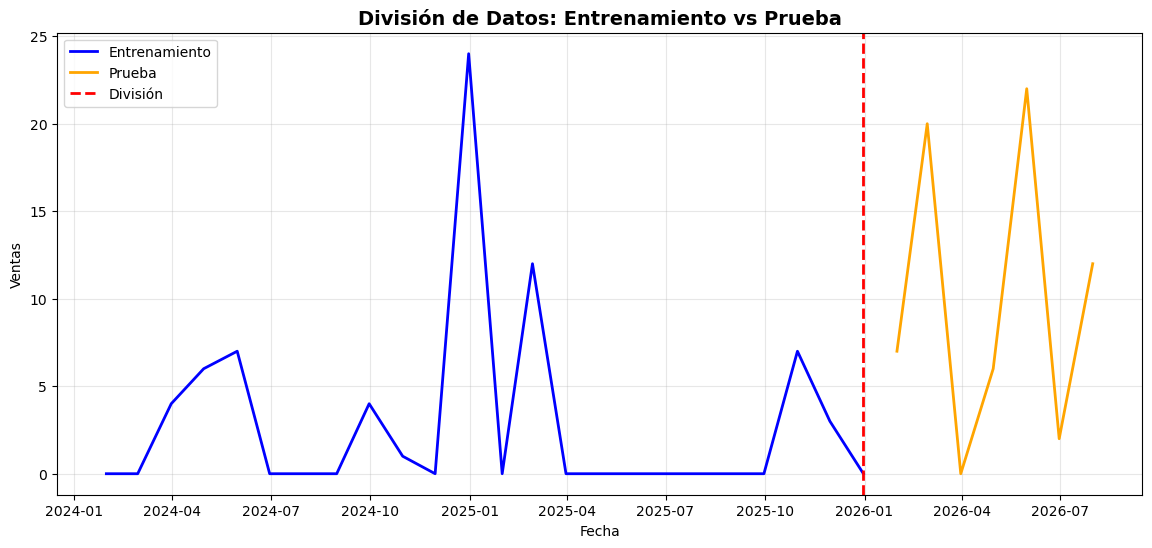

In [404]:
# Dividir en entrenamiento (80%) y prueba (20%)
train_size = int(len(df_codigo_ejemplo) * 0.8)
train_time = df_codigo_ejemplo.iloc[:train_size]['fecha_mes'].values
train_data = df_codigo_ejemplo.iloc[:train_size]['venta_mensual'].values
test_data = df_codigo_ejemplo.iloc[train_size:]['venta_mensual'].values
test_time = df_codigo_ejemplo.iloc[train_size:]['fecha_mes'].values
test_index = df_codigo_ejemplo.iloc[train_size:].index
corte=df_codigo_ejemplo.iloc[train_size-1]['fecha_mes']

print(f"Entrenamiento: {train_size} observaciones ({df_codigo_ejemplo.index[0]} a {df_codigo_ejemplo.index[train_size-1]})")
print(f"Prueba: {len(test_data)} observaciones ({test_index[0]} a {test_index[-1]})")

# Visualizar la división
plt.figure(figsize=(14, 6))
plt.plot(train_time, train_data, label='Entrenamiento', linewidth=2, color='blue')
plt.plot(test_time, test_data, label='Prueba', linewidth=2, color='orange')
plt.axvline(x=corte, color='red', linestyle='--', linewidth=2, label='División')
plt.title('División de Datos: Entrenamiento vs Prueba', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [405]:
# ============================================================
# Preparar dataframe para StatsForecast
# ============================================================

df_sf = df_series_long.rename(
    columns={
        "codigo_articulo": "unique_id",
        "fecha_mes": "ds",
        "venta_mensual": "y"
    }
)[["unique_id", "ds", "y"]].copy()

df_sf["ds"] = pd.to_datetime(df_sf["ds"])
df_sf["y"] = pd.to_numeric(df_sf["y"], errors="coerce").fillna(0)

df_sf = df_sf.sort_values(["unique_id", "ds"]).reset_index(drop=True)

df_sf.head()

,unique_id,ds,y
0,0225-3M,2024-01-31,0.0
1,0225-3M,2024-02-29,0.0
2,0225-3M,2024-03-31,0.0
3,0225-3M,2024-04-30,0.0
4,0225-3M,2024-05-31,0.0


In [406]:
# ============================================================
# Separar train/test para evaluación
# ============================================================

horizonte_meses=6

fechas_ordenadas = df_sf["ds"].sort_values().unique()

fechas_test = fechas_ordenadas[-horizonte_meses:]
fechas_train = fechas_ordenadas[:-horizonte_meses]


df_train = df_sf[df_sf["ds"].isin(fechas_train)].copy()
df_test = df_sf[df_sf["ds"].isin(fechas_test)].copy()

print("Rango de fechas en el conjunto de entrenamiento:")
print(f"  - Inicio: {df_train['ds'].min()}")
print(f"  - Fin: {df_train['ds'].max()}")

print("\nRango de fechas en el conjunto de prueba:")
print(f"  - Inicio: {df_test['ds'].min()}")
print(f"  - Fin: {df_test['ds'].max()}")

Rango de fechas en el conjunto de entrenamiento:
  - Inicio: 2024-01-31 00:00:00
  - Fin: 2026-01-31 00:00:00

Rango de fechas en el conjunto de prueba:
  - Inicio: 2026-02-28 00:00:00
  - Fin: 2026-07-31 00:00:00


In [407]:
# ============================================================
# Promedio de venta mensual por código en período train
# ============================================================
def calculo_venta_promedio_train_Xmeses(df_train, meses=24):
    """
    Calcula el promedio de venta mensual por código de artículo en el período de entrenamiento.
    """
    df_temp = df_train.copy()

    # Asegurar formato fecha
    df_temp["ds"] = pd.to_datetime(df_temp["ds"])

    # Asegurar formato numérico
    df_temp["y"] = pd.to_numeric(df_temp["y"], errors="coerce").fillna(0)

    # Ordenar por artículo y fecha
    df_temp = df_temp.sort_values(
        by=["unique_id", "ds"]
    ).reset_index(drop=True)

    # Tomar últimos meses por cada artículo
    df_train_last_meses = (
        df_temp
        .groupby("unique_id", group_keys=False)
        .tail(meses)
        .copy()
    )

    # Calcular promedio sobre esos últimos 24 meses
    df_promedio_train = (
        df_train_last_meses
        .groupby("unique_id")
        .agg(
            **{
            f"fecha_inicio_train_{meses}m": ("ds", "min"),
            f"fecha_fin_train_{meses}m": ("ds", "max"),
            f"venta_total_train_{meses}m": ("y", "sum"),
            f"cantidad_meses_train_{meses}m": ("y", "count"),
            f"promedio_venta_train_{meses}m": ("y", "mean")
            }
        )
        .reset_index()
    )

    return df_promedio_train[["unique_id", f"promedio_venta_train_{meses}m"]]

In [408]:
df_prueba=calculo_venta_promedio_train_Xmeses(df_train, meses=7)
df_prueba.head()

,unique_id,promedio_venta_train_7m
0,0225-3M,4.571429
1,0270H,194.714286
2,0384-3M-JASON,25.000000
3,0390H-JASON,0.000000
4,0420H,23.285714


In [409]:
df_test.head()

,unique_id,ds,y
25,0225-3M,2026-02-28,24.0
26,0225-3M,2026-03-31,0.0
27,0225-3M,2026-04-30,0.0
28,0225-3M,2026-05-31,24.0
29,0225-3M,2026-06-30,9.0


In [410]:
def dummy_model_X_meses(df, dummy_meses=24, horizonte_evaluacion=6):
    """
    Modelo dummy que predice la media de los últimos 24 meses.
    """
    fechas_ordenadas = df["ds"].sort_values().unique()

    fechas_test = fechas_ordenadas[-horizonte_evaluacion:]
    fechas_train = fechas_ordenadas[:-horizonte_evaluacion]

    df_train = df[df["ds"].isin(fechas_train)].copy()
    df_test = df[df["ds"].isin(fechas_test)].copy()
    df_dummy_xmeses = calculo_venta_promedio_train_Xmeses(df_train, meses=dummy_meses)
    df_evaluacion = df_test.merge(
        df_dummy_xmeses[["unique_id", f"promedio_venta_train_{dummy_meses}m"]],
        on=["unique_id"],
        how="left",
        validate="many_to_one"
        )
   
    return df_evaluacion

In [411]:
dummy_meses=24

df_dummy_mean_last24m = dummy_model_X_meses(df_sf, dummy_meses=dummy_meses, horizonte_evaluacion=6)


In [412]:
# ============================================================
# Entrenar modelos intermitentes con StatsForecast
# ============================================================
from statsforecast import StatsForecast
from statsforecast.models import CrostonClassic, CrostonOptimized, CrostonSBA, IMAPA, TSB

modelos_intermitentes = [
    CrostonClassic(),
    CrostonOptimized(),
    CrostonSBA(),
    IMAPA(),
    TSB(alpha_d=0.1, alpha_p=0.1)
]

sf = StatsForecast(
    models=modelos_intermitentes,
    freq="ME",
    n_jobs=-1
)

sf.fit(df=df_train)

df_forecast_intermitente = sf.predict(h=horizonte_meses)

df_forecast_intermitente.head(31)

,unique_id,ds,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB
0,0225-3M,2026-02-28,4.102279,7.274137,3.897165,6.304302,7.177438
1,0225-3M,2026-03-31,4.102279,7.274137,3.897165,6.304302,7.177438
2,0225-3M,2026-04-30,4.102279,7.274137,3.897165,6.304302,7.177438
3,0225-3M,2026-05-31,4.102279,7.274137,3.897165,6.304302,7.177438
4,0225-3M,2026-06-30,4.102279,7.274137,3.897165,6.304302,7.177438
5,0225-3M,2026-07-31,4.102279,7.274137,3.897165,6.304302,7.177438
6,0270H,2026-02-28,67.138213,175.179982,63.781303,176.098754,111.112794
7,0270H,2026-03-31,67.138213,175.179982,63.781303,176.098754,111.112794
8,0270H,2026-04-30,67.138213,175.179982,63.781303,176.098754,111.112794
9,0270H,2026-05-31,67.138213,175.179982,63.781303,176.098754,111.112794


In [413]:
# ============================================================
# Convertir predicciones intermitentes a números enteros
# ============================================================
# Recomendación operativa:
# - np.ceil(): redondea hacia arriba para evitar subestimar necesidad.
# - round(): redondeo normal.
#
# Para inventario/reabastecimiento normalmente se recomienda ceil.
# ============================================================

columnas_modelos_intermitentes = [
    col for col in df_forecast_intermitente.columns
    if col not in ["unique_id", "ds"]
]

for col in columnas_modelos_intermitentes:
    df_forecast_intermitente[col] = (
        np.ceil(df_forecast_intermitente[col])
        .clip(lower=0)
        .astype(int)
    )

df_forecast_intermitente.head(6)

,unique_id,ds,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB
0,0225-3M,2026-02-28,5,8,4,7,8
1,0225-3M,2026-03-31,5,8,4,7,8
2,0225-3M,2026-04-30,5,8,4,7,8
3,0225-3M,2026-05-31,5,8,4,7,8
4,0225-3M,2026-06-30,5,8,4,7,8
5,0225-3M,2026-07-31,5,8,4,7,8


In [414]:
df_test

,unique_id,ds,y
25,0225-3M,2026-02-28,24.0
26,0225-3M,2026-03-31,0.0
27,0225-3M,2026-04-30,0.0
28,0225-3M,2026-05-31,24.0
29,0225-3M,2026-06-30,9.0
...,...,...,...
13945,XPZ1400,2026-03-31,0.0
13946,XPZ1400,2026-04-30,0.0
13947,XPZ1400,2026-05-31,0.0
13948,XPZ1400,2026-06-30,0.0


In [502]:
# ============================================================
# Unir predicción contra test real
# ============================================================
df_evaluacion = df_test.merge(
    df_forecast_intermitente,
    on=["unique_id", "ds"],
)
df_evaluacion.head(10)

,unique_id,ds,y,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB
0,0225-3M,2026-02-28,24.0,5,8,4,7,8
1,0270H,2026-02-28,38.0,68,176,64,177,112
2,0384-3M-JASON,2026-02-28,0.0,7,18,7,24,21
3,0390H-JASON,2026-02-28,25.0,9,23,9,17,15
4,0420H,2026-02-28,0.0,9,15,8,19,19
5,0475-5M,2026-02-28,0.0,24,49,23,39,31
6,0475-5M-JASON,2026-02-28,0.0,34,33,33,28,27
7,0480-3M,2026-02-28,11.0,20,34,19,39,40
8,0510H-JASON,2026-02-28,0.0,58,36,55,23,47
9,0535-5M-JASON,2026-02-28,13.0,26,26,25,27,21


In [416]:
# ============================================================
# Unir predicción contra test real
# ============================================================
df_evaluacion_con_dummy = df_evaluacion.merge(
   df_dummy_mean_last24m[["unique_id", "ds", f"promedio_venta_train_24m"]],
   on =["unique_id", "ds"]
)
df_evaluacion_con_dummy.head(12)

,unique_id,ds,y,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB,promedio_venta_train_24m
0,0225-3M,2026-02-28,24.0,5,8,4,7,8,8.750000
1,0225-3M,2026-03-31,0.0,5,8,4,7,8,8.750000
2,0225-3M,2026-04-30,0.0,5,8,4,7,8,8.750000
3,0225-3M,2026-05-31,24.0,5,8,4,7,8,8.750000
4,0225-3M,2026-06-30,9.0,5,8,4,7,8,8.750000
5,0225-3M,2026-07-31,0.0,5,8,4,7,8,8.750000
6,0270H,2026-02-28,38.0,68,176,64,177,112,121.458333
7,0270H,2026-03-31,200.0,68,176,64,177,112,121.458333
8,0270H,2026-04-30,19.0,68,176,64,177,112,121.458333
9,0270H,2026-05-31,0.0,68,176,64,177,112,121.458333


In [417]:
# ============================================================
# Redondear hacia arriba para uso operativo
# ============================================================
df_evaluacion_con_dummy= df_evaluacion_con_dummy.rename(columns={"promedio_venta_train_24m": "Dummy_promedio_24m"})


df_evaluacion_con_dummy["Dummy_promedio_24m"] = (
    np.ceil(df_evaluacion_con_dummy["Dummy_promedio_24m"])
    .clip(lower=0)
    .astype(int)
)
#df_evaluacion_con_dummy= df_evaluacion_con_dummy.rename(columns={"promedio_venta_train_24m_ceil": "Dummy_promedio_24m"})
#df_evaluacion_con_dummy=df_evaluacion_con_dummy.drop(columns=["promedio_venta_train_24m"]).copy()
df_evaluacion_con_dummy.head()


,unique_id,ds,y,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB,Dummy_promedio_24m
0,0225-3M,2026-02-28,24.0,5,8,4,7,8,9
1,0225-3M,2026-03-31,0.0,5,8,4,7,8,9
2,0225-3M,2026-04-30,0.0,5,8,4,7,8,9
3,0225-3M,2026-05-31,24.0,5,8,4,7,8,9
4,0225-3M,2026-06-30,9.0,5,8,4,7,8,9


In [504]:
df_evaluacion_con_dummy


,unique_id,ds,y,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB,Dummy_promedio_24m
0,0225-3M,2026-02-28,24.0,5,8,4,7,8,9
1,0225-3M,2026-03-31,0.0,5,8,4,7,8,9
2,0225-3M,2026-04-30,0.0,5,8,4,7,8,9
3,0225-3M,2026-05-31,24.0,5,8,4,7,8,9
4,0225-3M,2026-06-30,9.0,5,8,4,7,8,9
...,...,...,...,...,...,...,...,...,...
2695,XPZ1400,2026-03-31,0.0,6,5,5,5,5,5
2696,XPZ1400,2026-04-30,0.0,6,5,5,5,5,5
2697,XPZ1400,2026-05-31,0.0,6,5,5,5,5,5
2698,XPZ1400,2026-06-30,0.0,6,5,5,5,5,5


In [419]:
# ============================================================
# Definir columnas de modelos a evaluar
# ============================================================

columnas_modelos=[
    "CrostonClassic",
    "CrostonOptimized",
    "CrostonSBA",
    "IMAPA",
    "TSB",
    "Dummy_promedio_24m"
]

columnas_modelos_evaluar = [
    col for col in columnas_modelos
    if col in df_evaluacion_con_dummy.columns
]

columnas_modelos_evaluar ## Creando una lista de los modelos a evaluar

['CrostonClassic',
 'CrostonOptimized',
 'CrostonSBA',
 'IMAPA',
 'TSB',
 'Dummy_promedio_24m']

In [420]:
df_evaluacion_acumulado_articulo=(df_evaluacion_con_dummy.groupby("unique_id", as_index=False).agg(
            venta_real_test=("y", "sum"),
            **{
                f"pred_{modelo}": (modelo, "sum") 
                for modelo in columnas_modelos_evaluar
            }

))
df_evaluacion_acumulado_articulo["venta_real_test"]=df_evaluacion_acumulado_articulo["venta_real_test"].astype(int)
df_evaluacion_acumulado_articulo.head(5)

,unique_id,venta_real_test,pred_CrostonClassic,pred_CrostonOptimized,pred_CrostonSBA,pred_IMAPA,pred_TSB,pred_Dummy_promedio_24m
0,0225-3M,57,30,48,24,42,48,54
1,0270H,907,408,1056,384,1062,672,732
2,0384-3M-JASON,0,42,108,42,144,126,78
3,0390H-JASON,391,54,138,54,102,90,126
4,0420H,19,54,90,48,114,114,90


In [421]:
df_evaluacion_con_dummy

,unique_id,ds,y,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB,Dummy_promedio_24m
0,0225-3M,2026-02-28,24.0,5,8,4,7,8,9
1,0225-3M,2026-03-31,0.0,5,8,4,7,8,9
2,0225-3M,2026-04-30,0.0,5,8,4,7,8,9
3,0225-3M,2026-05-31,24.0,5,8,4,7,8,9
4,0225-3M,2026-06-30,9.0,5,8,4,7,8,9
...,...,...,...,...,...,...,...,...,...
2695,XPZ1400,2026-03-31,0.0,6,5,5,5,5,5
2696,XPZ1400,2026-04-30,0.0,6,5,5,5,5,5
2697,XPZ1400,2026-05-31,0.0,6,5,5,5,5,5
2698,XPZ1400,2026-06-30,0.0,6,5,5,5,5,5


In [505]:
# ============================================================
# Convertir predicciones a formato largo
# ============================================================

cols_basicas=[
    "unique_id",
    "ds",
    "y"
]

cols_basicas= [col for col in df_evaluacion_con_dummy.columns 
               if col in cols_basicas]

df_eval_long = df_evaluacion_con_dummy.melt(
    id_vars=cols_basicas,
    value_vars=columnas_modelos_evaluar,
    var_name="modelo",
    value_name="y_pred"
)
df_eval_long["y"]=pd.to_numeric(df_eval_long["y"], errors="coerce").fillna(0)
df_eval_long["y_pred"]=pd.to_numeric(df_eval_long["y_pred"], errors="coerce").fillna(0)

display(df_eval_long[df_eval_long["unique_id"]=="0225-3M"].tail(10))

,unique_id,ds,y,modelo,y_pred
10802,0225-3M,2026-04-30,0.0,TSB,8
10803,0225-3M,2026-05-31,24.0,TSB,8
10804,0225-3M,2026-06-30,9.0,TSB,8
10805,0225-3M,2026-07-31,0.0,TSB,8
13500,0225-3M,2026-02-28,24.0,Dummy_promedio_24m,9
13501,0225-3M,2026-03-31,0.0,Dummy_promedio_24m,9
13502,0225-3M,2026-04-30,0.0,Dummy_promedio_24m,9
13503,0225-3M,2026-05-31,24.0,Dummy_promedio_24m,9
13504,0225-3M,2026-06-30,9.0,Dummy_promedio_24m,9
13505,0225-3M,2026-07-31,0.0,Dummy_promedio_24m,9


In [423]:
df_0225_3M_CrostonClassic=df_eval_long[(df_eval_long["unique_id"]=="0225-3M") & (df_eval_long["modelo"]=="CrostonClassic")].copy()

In [424]:
articulos=df_eval_long["unique_id"].dropna().unique().tolist()
print(articulos)
print(len(articulos))

['0225-3M', '0270H', '0384-3M-JASON', '0390H-JASON', '0420H', '0475-5M', '0475-5M-JASON', '0480-3M', '0510H-JASON', '0535-5M-JASON', '0550-5M-JASON', '0570H', '0600-8M', '0630H-JASON', '0656-8M', '0660H', '07100S', '0720-8M', '0760-8M', '0800-8M', '0800-S8M', "08B-1R-10'-TSU", '0960-8M', '1.0HP18RB-S-ODP', '1/4-20X1-1/4 FANGZNC', '1040-8M', '10B-2-CL-TSU', '1100H-JASON', '1120-S8M', '11X5 CC-HD POLY', '1200-8M', '1212KC3', '1250H-JASON', '1280-8M', '1400-S8M-JASON', '1440-8M', '145TTFB16030-WX', '150XL', '1600-8M', '16006C3', '1700H', '1760-8M', '190XL-JASON', '1A-24', '2000-5M-JASON', '20000 140 E', '20001 190 E', '20004 1 1/2E', '20005 2"E', '2014-07-01 00:00:00', '2024-07-01 00:00:00', '2100-14M', '210L', '25-5M-OES', '255L', '32T10-OES', '345DL', '345L', '345L-JASON', '367L', '375XJ24NC', '3L190', '3L200', '3L210', '3L220', '3L240', '3L250', '3L260', '3NA3822', '3NA3830', '3NA3832', '3RH21221BB40', '3RH21311BB40', '3RH21401BB40', '3RH29111HA22', '3RP25051AW30', '3RT20151AP01', '3RT

In [425]:
def crear_df_por_articulo_modelo(df, codigo_articulo, modelo):
    """
    Crea un DataFrame filtrado por código de artículo y modelo.
    """
    df_filtrado = df[
        (df["unique_id"] == codigo_articulo) &
        (df["modelo"] == modelo)
    ].copy()
    
    return df_filtrado

In [426]:
df_0225_3M_CrostonOptimized=crear_df_por_articulo_modelo(df_eval_long, "0225-3M", "CrostonOptimized")
df_0225_3M_CrostonOptimized["error_abs"]=np.abs(df_0225_3M_CrostonOptimized["y"]-df_0225_3M_CrostonOptimized["y_pred"])
df_0225_3M_CrostonOptimized.head(10)
mae=df_0225_3M_CrostonOptimized["error_abs"].mean()
print(df_0225_3M_CrostonOptimized)
print(df_0225_3M_CrostonOptimized["error_abs"].sum())
print(mae)


     unique_id         ds     y            modelo  y_pred  error_abs
2700   0225-3M 2026-02-28  24.0  CrostonOptimized       8       16.0
2701   0225-3M 2026-03-31   0.0  CrostonOptimized       8        8.0
2702   0225-3M 2026-04-30   0.0  CrostonOptimized       8        8.0
2703   0225-3M 2026-05-31  24.0  CrostonOptimized       8       16.0
2704   0225-3M 2026-06-30   9.0  CrostonOptimized       8        1.0
2705   0225-3M 2026-07-31   0.0  CrostonOptimized       8        8.0
57.0
9.5


In [427]:
df_0225_3M_CrostonSBA=crear_df_por_articulo_modelo(df_eval_long, "0225-3M", "CrostonSBA")
df_0225_3M_CrostonSBA["error_abs"]=np.abs(df_0225_3M_CrostonSBA["y"]-df_0225_3M_CrostonSBA["y_pred"])
mae=df_0225_3M_CrostonSBA["error_abs"].mean()
print(df_0225_3M_CrostonSBA)
print(df_0225_3M_CrostonSBA["error_abs"].sum())
print(mae)


     unique_id         ds     y      modelo  y_pred  error_abs
5400   0225-3M 2026-02-28  24.0  CrostonSBA       4       20.0
5401   0225-3M 2026-03-31   0.0  CrostonSBA       4        4.0
5402   0225-3M 2026-04-30   0.0  CrostonSBA       4        4.0
5403   0225-3M 2026-05-31  24.0  CrostonSBA       4       20.0
5404   0225-3M 2026-06-30   9.0  CrostonSBA       4        5.0
5405   0225-3M 2026-07-31   0.0  CrostonSBA       4        4.0
57.0
9.5


In [428]:
import string

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calcular_metricas(df_articulo_modelo_filtrado):
    """
    Evalúa métricas de error para un DataFrame filtrado por artículo y modelo.
    """
    # Asegurar formato numérico
    df=df_articulo_modelo_filtrado.copy()
    df["y"] = pd.to_numeric(df["y"], errors="coerce").fillna(0)
    df["y_pred"] = pd.to_numeric(df["y_pred"], errors="coerce").fillna(0)
    venta_real_total = int(df["y"].sum())
    prediccion_total = int(df["y_pred"].sum())


    # Crear métricas de desempate

    bias_total_periodo_evaluacion=float(venta_real_total-prediccion_total)
    # abs_bias_total_periodo_evaluacio=bias_total_periodo_evaluacion.abs()

    # #df["bias_total"] = df["y"] - df["y_pred"]

    # #df["abs_bias_total"] = df["bias_total"].abs()
    if bias_total_periodo_evaluacion < 0:
        sesgo = "Sobrepronóstico"
    elif bias_total_periodo_evaluacion > 0:
        sesgo = "Subpronóstico"
    else:
        sesgo = "Exacto"


    # df["tipo_sesgo"] = np.where(
    #     df["bias_total"] > 0,
    #     "Subpronóstico",
    #     np.where(
    #         df["bias_total"] < 0,
    #         "Sobrepronóstico",
    #         "Exacto"
    #     )
    # )

    # Calcular métricas
    mse = mean_squared_error(df["y"], df["y_pred"])
    rmse = np.sqrt(mse)
    mae = np.abs(df["y"] - df["y_pred"]).mean()
    error_absoluto_total=mae * len(df)

    r2 = r2_score(df["y"], df["y_pred"])
    
    mape = np.mean(np.abs((df["y"] - df["y_pred"]) / df["y"].replace(0, np.nan))) * 100

     # WAPE estándar
    if venta_real_total != 0:
        wape = error_absoluto_total / venta_real_total * 100
    else:
        wape = np.nan

    # WAPE para ranking operativo
    # Si no hubo venta real y el modelo predijo 0, es perfecto.
    # Si no hubo venta real y el modelo predijo más de 0, lo castigamos con infinito.
    if venta_real_total == 0 and prediccion_total == 0:
        wape_ranking = 0
        caso_demanda_test = "Sin demanda real y predicción cero, Wappe perfecto "
    elif venta_real_total == 0 and prediccion_total > 0:
        wape_ranking = np.inf
        caso_demanda_test = "Sin demanda real en test con sobrepronóstico Wape infinito"
    else:
        wape_ranking = wape
        caso_demanda_test = "Con demanda real en test y pronóstico"


    Serie_filtrada_con_metricas = pd.Series({
        "unique_id": df["unique_id"].iloc[0],
        "modelo": df["modelo"].iloc[0],
        "y_real":venta_real_total,
        "y_pred":prediccion_total,
        "MSE": float(f"{mse:.2f}"),
        "RMSE": float(f"{rmse:.2f}"),
        "MAE": float(f"{mae:.2f}"),
        "MAPE": float(f"{mape:.2f}"),
        "error_absoluto_total": float(f"{error_absoluto_total:.2f}"),
        "WAPE": float(f"{wape:.2f}"),
        "WAPE_ranking": float(f"{wape_ranking:.2f}"),
        "caso_demanda_test": caso_demanda_test,
        "bias_total_abs_periodo_evaluacion":float(f"{abs(bias_total_periodo_evaluacion):.2f}"),
        "sesgo":sesgo
    })

    df_metricas_articulo_modelo= Serie_filtrada_con_metricas.to_frame().T
    return df_metricas_articulo_modelo
    

In [429]:
prueba=calcular_metricas(df_0225_3M_CrostonSBA)
prueba.head(10)

,unique_id,modelo,y_real,y_pred,MSE,RMSE,MAE,MAPE,error_absoluto_total,WAPE,WAPE_ranking,caso_demanda_test,bias_total_abs_periodo_evaluacion,sesgo
0,0225-3M,CrostonSBA,57,24,145.5,12.06,9.5,74.07,57.0,100.0,100.0,Con demanda real en test y pronóstico,33.0,Subpronóstico


In [430]:
df_0225_3M_con_metricas=calcular_metricas(df_0225_3M_CrostonClassic)
df_0225_3M_con_metricas.head()

,unique_id,modelo,y_real,y_pred,MSE,RMSE,MAE,MAPE,error_absoluto_total,WAPE,WAPE_ranking,caso_demanda_test,bias_total_abs_periodo_evaluacion,sesgo
0,0225-3M,CrostonClassic,57,30,135.5,11.64,9.5,67.59,57.0,100.0,100.0,Con demanda real en test y pronóstico,27.0,Subpronóstico


In [539]:
def evaluando_metricas_por_articulo_modelo(df):
    lista_resultados=[]
    articulos=df["unique_id"].dropna().unique().tolist()
    modelos=df["modelo"].dropna().unique().tolist()
  

    for articulo in articulos:
        for modelo in modelos:
            df_filtrado = crear_df_por_articulo_modelo(df, articulo, modelo)
            df_metricas_articulo_modelo=calcular_metricas(df_filtrado)
            lista_resultados.append(df_metricas_articulo_modelo)

    df_metricas = pd.concat(
    lista_resultados,
    axis=0,
    ignore_index=True
) 
    return df_metricas
           

In [540]:
df_metricas=evaluando_metricas_por_articulo_modelo(df_eval_long).sort_values("bias_total_abs_periodo_evaluacion", ascending=True)
df_metricas.head(20)

,unique_id,modelo,y_real,y_pred,MSE,RMSE,MAE,MAPE,error_absoluto_total,WAPE,WAPE_ranking,caso_demanda_test,bias_total_abs_periodo_evaluacion,sesgo
1875,CNHM-2-6105-YA-EP-25,IMAPA,6,6,1.0,1.0,1.0,50.0,6.0,100.0,100.0,Con demanda real en test y pronóstico,0.0,Exacto
1304,63092RSC3,CrostonSBA,24,24,19.0,4.36,4.0,113.33,24.0,100.0,100.0,Con demanda real en test y pronóstico,0.0,Exacto
1303,63092RSC3,CrostonOptimized,24,24,19.0,4.36,4.0,113.33,24.0,100.0,100.0,Con demanda real en test y pronóstico,0.0,Exacto
1302,63092RSC3,CrostonClassic,24,24,19.0,4.36,4.0,113.33,24.0,100.0,100.0,Con demanda real en test y pronóstico,0.0,Exacto
1301,6308ZZC3,Dummy_promedio_24m,24,24,13.33,3.65,3.33,56.67,20.0,83.33,83.33,Con demanda real en test y pronóstico,0.0,Exacto
1289,6307ZZC3,Dummy_promedio_24m,12,12,7.0,2.65,2.33,73.81,14.0,116.67,116.67,Con demanda real en test y pronóstico,0.0,Exacto
1288,6307ZZC3,TSB,12,12,7.0,2.65,2.33,73.81,14.0,116.67,116.67,Con demanda real en test y pronóstico,0.0,Exacto
1287,6307ZZC3,IMAPA,12,12,7.0,2.65,2.33,73.81,14.0,116.67,116.67,Con demanda real en test y pronóstico,0.0,Exacto
1285,6307ZZC3,CrostonOptimized,12,12,7.0,2.65,2.33,73.81,14.0,116.67,116.67,Con demanda real en test y pronóstico,0.0,Exacto
1284,6307ZZC3,CrostonClassic,12,12,7.0,2.65,2.33,73.81,14.0,116.67,116.67,Con demanda real en test y pronóstico,0.0,Exacto


In [433]:
def mejor_modelo_por_articulo(df_metricas):
    """
    Selecciona el mejor modelo por artículo basado en WAPE_ranking.
    """
    df_mejor_modelo = (
        df_metricas
        .sort_values(by=["unique_id", "WAPE_ranking", "bias_total_abs_periodo_evaluacion", "RMSE", "MAE"], ascending=[True, True, True, True, True])
        .groupby("unique_id", as_index=False)
        .first()
    )
    df_mejor_modelo=df_mejor_modelo.rename(columns={"modelo": "best_model"})
    
    return df_mejor_modelo

In [434]:
df_best_model_por_articulo = mejor_modelo_por_articulo(df_metricas).sort_values("bias_total_abs_periodo_evaluacion", ascending=True).reset_index(drop=True)
df_best_model_por_articulo=df_best_model_por_articulo.rename(columns={"unique_id":"codigo_articulo"}).copy()
df_best_model_por_articulo[df_best_model_por_articulo["codigo_articulo"]=="0225-3M"]

,codigo_articulo,best_model,y_real,y_pred,MSE,RMSE,MAE,MAPE,error_absoluto_total,WAPE,WAPE_ranking,caso_demanda_test,bias_total_abs_periodo_evaluacion,sesgo
99,0225-3M,Dummy_promedio_24m,57,54,115.5,10.75,9.5,41.67,57.0,100.0,100.0,Con demanda real en test y pronóstico,3.0,Subpronóstico


In [435]:
df_best_model_por_articulo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   codigo_articulo                    450 non-null    object
 1   best_model                         450 non-null    object
 2   y_real                             450 non-null    object
 3   y_pred                             450 non-null    object
 4   MSE                                450 non-null    object
 5   RMSE                               450 non-null    object
 6   MAE                                450 non-null    object
 7   MAPE                               421 non-null    object
 8   error_absoluto_total               450 non-null    object
 9   WAPE                               421 non-null    object
 10  WAPE_ranking                       450 non-null    object
 11  caso_demanda_test                  450 non-null    object
 12  bias_tot

In [436]:
df_best_model_por_articulo = mejor_modelo_por_articulo(df_metricas).sort_values(by="bias_total_abs_periodo_evaluacion", ascending=True).reset_index(drop=True)
print("=="*60)
print("Resumen de mejores modelos por artículo basado en WAPE_ranking:")

Resumen_mejores_modelos = (
    df_best_model_por_articulo["best_model"]
    .value_counts()
    .reset_index()
)

Resumen_mejores_modelos.columns = ["modelo", "cantidad"]

Resumen_mejores_modelos["porcentaje"]=round(Resumen_mejores_modelos["cantidad"]/Resumen_mejores_modelos["cantidad"].sum()*100,2)
print(Resumen_mejores_modelos)

Resumen de mejores modelos por artículo basado en WAPE_ranking:
               modelo  cantidad  porcentaje
0  Dummy_promedio_24m       112       24.89
1          CrostonSBA        84       18.67
2               IMAPA        79       17.56
3                 TSB        69       15.33
4      CrostonClassic        62       13.78
5    CrostonOptimized        44        9.78


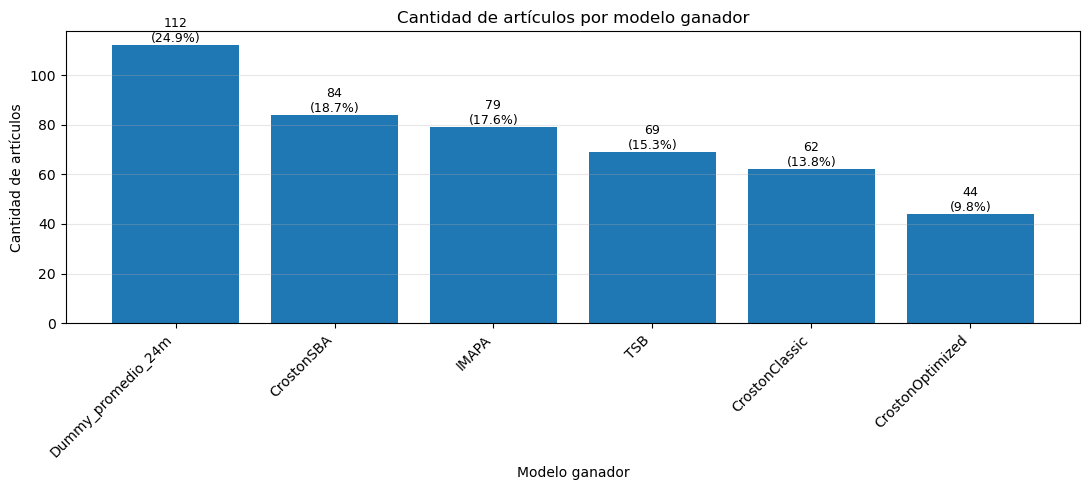

In [437]:
# ============================================================
# Gráfico de barras - modelo ganador
# ============================================================

df_plot_modelo_ganador = Resumen_mejores_modelos.sort_values(
    "cantidad",
    ascending=False
)

plt.figure(figsize=(11, 5))

plt.bar(
    df_plot_modelo_ganador["modelo"],
    df_plot_modelo_ganador["cantidad"]
)

plt.title("Cantidad de artículos por modelo ganador")
plt.xlabel("Modelo ganador")
plt.ylabel("Cantidad de artículos")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, fila in df_plot_modelo_ganador.reset_index(drop=True).iterrows():
    plt.text(
        i,
        fila["cantidad"],
        f"{int(fila['cantidad'])}\n({fila['porcentaje']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

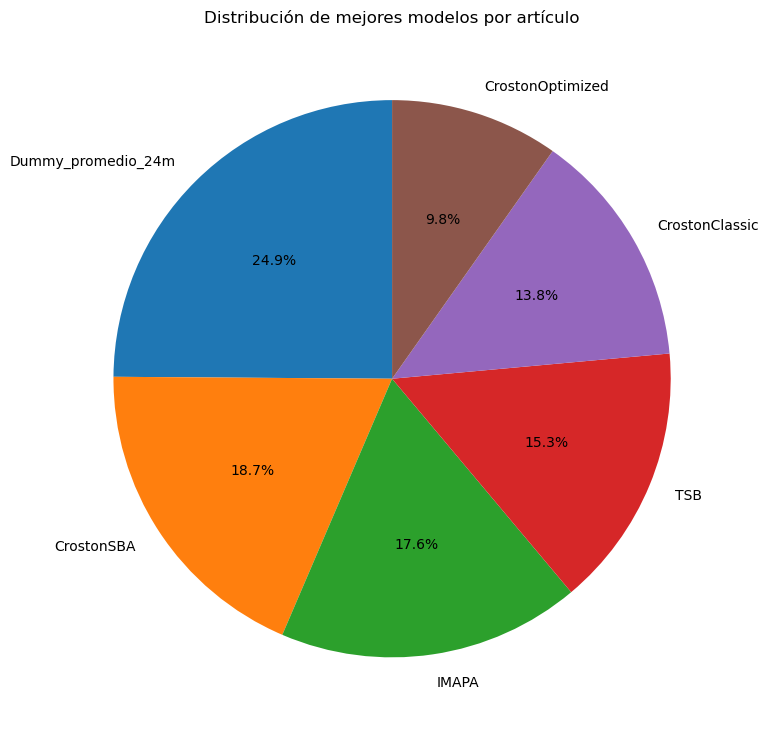

In [438]:
plt.figure(figsize=(8, 8))

plt.pie(
    Resumen_mejores_modelos["cantidad"],
    labels=Resumen_mejores_modelos["modelo"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribución de mejores modelos por artículo")
plt.tight_layout()

plt.show()

In [439]:
# # ============================================================
# # Comprobar cuantos articulos tienen MAPE=NAN ya que y_real=0
# # ============================================================
venta0_intervalo_Test=df_best_model_por_articulo[df_best_model_por_articulo["y_real"]==0].shape[0]
Qty_mape_Nan=df_best_model_por_articulo[df_best_model_por_articulo["MAPE"].isna()].shape[0]
#print(venta0_intervalo_Test)
if Qty_mape_Nan==venta0_intervalo_Test:
    print(f"La cantidad de articulos con venta igual a 0 en intervalo de evaluacion es igual a: {Qty_mape_Nan}, que corresponde a la misma cantidad de articulos con mape igual a NaN ")

La cantidad de articulos con venta igual a 0 en intervalo de evaluacion es igual a: 29, que corresponde a la misma cantidad de articulos con mape igual a NaN 


In [440]:
df=df.rename(columns={"codigo_articulo":"unique_id"}).copy()

In [441]:
dt=df_best_model_por_articulo[["unique_id","best_model"]]
dt.head()

,unique_id,best_model
0,D1270-RPP5-15,Dummy_promedio_24m
1,MS075,IMAPA
2,63042RS,Dummy_promedio_24m
3,6308ZZC3,Dummy_promedio_24m
4,20001 190 E,CrostonClassic


In [442]:
# # ============================================================
# # LLEVAMOS EL MODELO GANADOR A LA MATRIZ DE VENTA ORIGINAL
# # ============================================================
df_ventas_con_bst_model=df.merge(
    df_best_model_por_articulo[["unique_id", "best_model", "WAPE_ranking", "bias_total_abs_periodo_evaluacion", "sesgo"]],
    on=["unique_id"]
    
)
df_ventas_con_bst_model.head()

,unique_id,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,cluster_kmeans_final,descripcion_cluster,...,venta_2026_02,venta_2026_03,venta_2026_04,venta_2026_05,venta_2026_06,venta_2026_07,best_model,WAPE_ranking,bias_total_abs_periodo_evaluacion,sesgo
0,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",...,24.0,0.0,0.0,24.0,9.0,0.0,Dummy_promedio_24m,100.0,3.0,Subpronóstico
1,0270H,"Manga de sincronismo, 270H, longitud externa 2...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,2.0,Demanda activa y reciente con señales de creci...,...,38.0,200.0,19.0,0.0,300.0,350.0,CrostonOptimized,87.43,149.0,Sobrepronóstico
2,0384-3M-JASON,"Manga de sincronismo, 384-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,0.0,0.0,0.0,0.0,0.0,0.0,CrostonClassic,inf,42.0,Sobrepronóstico
3,0390H-JASON,"Manga de sincronismo, 390H, longitud externa 3...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,JASON,MM,2.0,Demanda activa y reciente con señales de creci...,...,25.0,0.0,201.0,25.0,140.0,0.0,CrostonOptimized,88.24,253.0,Subpronóstico
4,0420H,"Manga de sincronismo, 420H, longitud externa 4...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,0.0,0.0,19.0,0.0,0.0,0.0,CrostonSBA,268.42,29.0,Sobrepronóstico


In [518]:
df_ventas_con_bst_model=df_ventas_con_bst_model.rename(columns={"unique_id":"codigo_articulo"})

In [519]:
df_ventas_con_bst_model

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,cluster_kmeans_final,descripcion_cluster,...,venta_2026_02,venta_2026_03,venta_2026_04,venta_2026_05,venta_2026_06,venta_2026_07,best_model,WAPE_ranking,bias_total_abs_periodo_evaluacion,sesgo
0,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",...,24.00,0.00,0.00,24.0,9.00,0.0,Dummy_promedio_24m,100.0,3.0,Subpronóstico
1,0270H,"Manga de sincronismo, 270H, longitud externa 2...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,2.0,Demanda activa y reciente con señales de creci...,...,38.00,200.00,19.00,0.0,300.00,350.0,CrostonOptimized,87.43,149.0,Sobrepronóstico
2,0384-3M-JASON,"Manga de sincronismo, 384-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,0.00,0.00,0.00,0.0,0.00,0.0,CrostonClassic,inf,42.0,Sobrepronóstico
3,0390H-JASON,"Manga de sincronismo, 390H, longitud externa 3...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,JASON,MM,2.0,Demanda activa y reciente con señales de creci...,...,25.00,0.00,201.00,25.0,140.00,0.0,CrostonOptimized,88.24,253.0,Subpronóstico
4,0420H,"Manga de sincronismo, 420H, longitud externa 4...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,0.00,0.00,19.00,0.0,0.00,0.0,CrostonSBA,268.42,29.0,Sobrepronóstico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,W16H6,CM.Eje calibrado.16mm,BALEROS,CORREAS,REDONDAS,REDONDAS,INA,CM,1.0,"Demanda históricamente relevante, variable y c...",...,550.00,150.00,1000.00,200.0,100.00,0.0,CrostonSBA,84.0,260.0,Subpronóstico
446,W25H6,CM. Eje calibrado. diametro 25mm,BALEROS,CORREAS,REDONDAS,REDONDAS,INA,CM,2.0,Demanda activa y reciente con señales de creci...,...,300.00,600.00,190.00,100.0,350.00,0.0,CrostonOptimized,62.34,226.0,Subpronóstico
447,W30H6,CM.Eje Calibrado.30mm,BALEROS,CORREAS,REDONDAS,REDONDAS,INA,CM,2.0,Demanda activa y reciente con señales de creci...,...,700.00,1050.00,0.00,350.0,0.00,0.0,IMAPA,100.0,366.0,Subpronóstico
448,W8,"Cinta para husos, Habasit, W-8",FAJAS,BANDAS,CORREAS PLANAS DE TRANSMISION,CORREAS PLANAS DE TRANSMISION,HABASIT ROCUA,CM2,1.0,"Demanda históricamente relevante, variable y c...",...,197016.75,801122.44,305712.68,0.0,136393.95,0.0,IMAPA,84.32,117281.0,Subpronóstico


In [520]:
df_preparacion_formato=convertir_matriz_a_formato_largo(df_ventas_con_bst_model, columnas_venta)
df_preparacion_formato.head()

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,cluster_kmeans_final,descripcion_cluster,best_model,WAPE_ranking,bias_total_abs_periodo_evaluacion,sesgo,columna_venta,venta_mensual,fecha_mes
0,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",Dummy_promedio_24m,100.0,3.0,Subpronóstico,venta_2024_01,0.0,2024-01-31
1,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",Dummy_promedio_24m,100.0,3.0,Subpronóstico,venta_2024_02,0.0,2024-02-29
2,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",Dummy_promedio_24m,100.0,3.0,Subpronóstico,venta_2024_03,0.0,2024-03-31
3,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",Dummy_promedio_24m,100.0,3.0,Subpronóstico,venta_2024_04,0.0,2024-04-30
4,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",Dummy_promedio_24m,100.0,3.0,Subpronóstico,venta_2024_05,0.0,2024-05-31


In [ ]:
import pandas as pd
import numpy as np
import re

# ============================================================
# Función auxiliar: convertir venta_YYYY_MM a fecha fin de mes
# ============================================================

def convertir_columna_venta_a_fecha(columna):
    """
    Convierte una columna tipo venta_2024_01 a fecha fin de mes.
    """
    fecha = pd.to_datetime(
        columna.replace("venta_", "") + "_01",
        format="%Y_%m_%d"
    ) + pd.offsets.MonthEnd(0)

    return fecha


# ============================================================
# Preparar dataframe de inferencia y metadata por artículo
# ============================================================

def preparar_formato_forecast_y_metadata(
    df_consolidado,
    columna_codigo="codigo_articulo"
):
    """
    A partir de una matriz consolidada de artículos y ventas mensuales,
    genera:

    1. df_stats:
       DataFrame en formato StatsForecast:
       unique_id | ds | y

    2. df_metadata_articulos:
       DataFrame con una fila por artículo y toda la información
       no mensual.

    3. metadata_por_articulo:
       Diccionario clave-valor:
       unique_id -> información completa del artículo.

    4. mapa_fechas:
       DataFrame con equivalencia entre columnas de venta y fechas.

    Parámetros:
    - df_consolidado: dataframe matriz consolidada.
    - columna_codigo: nombre de la columna con el código del artículo.

    Retorna:
    - df_stats
    - df_metadata_articulos
    - metadata_por_articulo
    - mapa_fechas
    - columnas_venta
    """

    df_temp = df_consolidado.copy()

    # ------------------------------------------------------------
    # Si codigo_articulo está como índice, lo regresamos a columna
    # ------------------------------------------------------------

    if columna_codigo not in df_temp.columns:
        if df_temp.index.name == columna_codigo:
            df_temp = df_temp.reset_index()
        else:
            raise ValueError(
                f"No se encontró la columna {columna_codigo} en el dataframe."
            )

    # ------------------------------------------------------------
    # Detectar columnas mensuales tipo venta_YYYY_MM
    # ------------------------------------------------------------

    patron_venta = r"^venta_\d{4}_\d{2}$"

    columnas_venta = [
        col for col in df_temp.columns
        if re.match(patron_venta, str(col))
    ]

    if len(columnas_venta) == 0:
        raise ValueError(
            "No se encontraron columnas mensuales con formato venta_YYYY_MM."
        )

    # Ordenar columnas de venta cronológicamente
    columnas_venta = sorted(
        columnas_venta,
        key=lambda col: convertir_columna_venta_a_fecha(col)
    )

    # ------------------------------------------------------------
    # Crear mapa de fechas
    # ------------------------------------------------------------

    mapa_fechas = pd.DataFrame({
        "columna_venta": columnas_venta,
        "ds": [
            convertir_columna_venta_a_fecha(col)
            for col in columnas_venta
        ]
    })

    # ------------------------------------------------------------
    # Separar metadata: todo lo que no sea columna mensual
    # ------------------------------------------------------------

    columnas_metadata = [
        col for col in df_temp.columns
        if col not in columnas_venta
    ]

    df_metadata_articulos = (
        df_temp[columnas_metadata]
        .drop_duplicates(subset=[columna_codigo])
        .copy()
    )

    # Renombrar código a unique_id para mantener estándar
    df_metadata_articulos = df_metadata_articulos.rename(columns={columna_codigo: "unique_id"})
    #)

    # Validar que haya una sola fila por artículo
    duplicados = df_metadata_articulos["unique_id"].duplicated().sum()

    if duplicados > 0:
        raise ValueError(
            f"Hay {duplicados} códigos duplicados en metadata. "
            "Revisar antes de continuar."
        )

    # ------------------------------------------------------------
    # Crear diccionario clave-valor por artículo
    # ------------------------------------------------------------

    metadata_por_articulo = (
        df_metadata_articulos
        .set_index("unique_id")
        .to_dict(orient="index")
    )

    # ------------------------------------------------------------
    # Crear formato largo para inferencia
    # ------------------------------------------------------------

    df_inferencia = df_temp[
        [columna_codigo] + columnas_venta
    ].melt(
        id_vars=[columna_codigo],
        value_vars=columnas_venta,
        var_name="columna_venta",
        value_name="y"
    )

    df_inferencia["ds"] = df_inferencia["columna_venta"].map(
        dict(zip(mapa_fechas["columna_venta"], mapa_fechas["ds"]))
    )

    df_inferencia = df_inferencia.rename(columns={columna_codigo: "unique_id"})

    df_inferencia["y"] = pd.to_numeric(
        df_inferencia["y"],
        errors="coerce"
    ).fillna(0)

    df_inferencia = (
        df_inferencia[["unique_id", "ds", "y"]]
        .sort_values(["unique_id", "ds"])
        .reset_index(drop=True)
    )

    return (
        df_inferencia,
        df_metadata_articulos,
        metadata_por_articulo,
        mapa_fechas,
        columnas_venta
    )

In [522]:
df_inferencia, df_metadata_articulos, metadata_por_articulo, mapa_fechas, columnas_venta=preparar_datos_inferencia_y_metadata(df_ventas_con_bst_model)

In [534]:
df

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,cluster_kmeans_final,descripcion_cluster,...,venta_2025_10,venta_2025_11,venta_2025_12,venta_2026_01,venta_2026_02,venta_2026_03,venta_2026_04,venta_2026_05,venta_2026_06,venta_2026_07
0,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",...,6.00,12.00,0.00,0.00,24.00,0.00,0.00,24.0,9.00,0.0
1,0270H,"Manga de sincronismo, 270H, longitud externa 2...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,2.0,Demanda activa y reciente con señales de creci...,...,50.00,600.00,225.00,150.00,38.00,200.00,19.00,0.0,300.00,350.0
2,0384-3M-JASON,"Manga de sincronismo, 384-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,15.00,30.00,55.00,45.00,0.00,0.00,0.00,0.0,0.00,0.0
3,0390H-JASON,"Manga de sincronismo, 390H, longitud externa 3...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,JASON,MM,2.0,Demanda activa y reciente con señales de creci...,...,0.00,0.00,0.00,0.00,25.00,0.00,201.00,25.0,140.00,0.0
4,0420H,"Manga de sincronismo, 420H, longitud externa 4...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,38.00,0.00,0.00,50.00,0.00,0.00,19.00,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,W16H6,CM.Eje calibrado.16mm,BALEROS,CORREAS,REDONDAS,REDONDAS,INA,CM,1.0,"Demanda históricamente relevante, variable y c...",...,150.00,650.00,150.00,0.00,550.00,150.00,1000.00,200.0,100.00,0.0
446,W25H6,CM. Eje calibrado. diametro 25mm,BALEROS,CORREAS,REDONDAS,REDONDAS,INA,CM,2.0,Demanda activa y reciente con señales de creci...,...,350.00,700.00,300.00,100.00,300.00,600.00,190.00,100.0,350.00,0.0
447,W30H6,CM.Eje Calibrado.30mm,BALEROS,CORREAS,REDONDAS,REDONDAS,INA,CM,2.0,Demanda activa y reciente con señales de creci...,...,0.00,100.00,600.00,700.00,700.00,1050.00,0.00,350.0,0.00,0.0
448,W8,"Cinta para husos, Habasit, W-8",FAJAS,BANDAS,CORREAS PLANAS DE TRANSMISION,CORREAS PLANAS DE TRANSMISION,HABASIT ROCUA,CM2,1.0,"Demanda históricamente relevante, variable y c...",...,265753.43,348684.12,248249.93,87399.77,197016.75,801122.44,305712.68,0.0,136393.95,0.0


In [536]:
df_inferencia1, df_metadata_articulos, metadata_por_articulo, mapa_fechas, columnas_venta=preparar_datos_inferencia_y_metadata(df)


In [537]:
df_inferencia1

,unique_id,ds,y
0,0225-3M,2024-01-31,0.0
1,0225-3M,2024-02-29,0.0
2,0225-3M,2024-03-31,0.0
3,0225-3M,2024-04-30,0.0
4,0225-3M,2024-05-31,0.0
...,...,...,...
13945,XPZ1400,2026-03-31,0.0
13946,XPZ1400,2026-04-30,0.0
13947,XPZ1400,2026-05-31,0.0
13948,XPZ1400,2026-06-30,0.0


In [447]:
metadata_por_articulo["0225-3M"]

{'descripcion_completa': 'Manga de sincronismo, 225-3M, Longitud externa 225 mm, numero de dientes 75, jason',
 'grupo_articulo': 'FAJAS',
 'categoria': 'CORREAS',
 'subcategoria': 'SINCRONISMO',
 'tipo': 'DIENTE CURVILINEO',
 'marca_fabricante': 'JASON',
 'unidad_medida_inventario': 'MM',
 'cluster_kmeans_final': 1.0,
 'descripcion_cluster': 'Demanda históricamente relevante, variable y con posible desaceleración',
 'best_model': 'Dummy_promedio_24m',
 'WAPE_ranking': 100.0,
 'bias_total_abs_periodo_evaluacion': 3.0,
 'sesgo': 'Subpronóstico'}

In [448]:
df_metadata_articulo = pd.DataFrame(
    metadata_por_articulo["0225-3M"].items(),
    columns=["campo", "valor"]
)

df_metadata_articulo

,campo,valor
0,descripcion_completa,"Manga de sincronismo, 225-3M, Longitud externa..."
1,grupo_articulo,FAJAS
2,categoria,CORREAS
3,subcategoria,SINCRONISMO
4,tipo,DIENTE CURVILINEO
5,marca_fabricante,JASON
6,unidad_medida_inventario,MM
7,cluster_kmeans_final,1.0
8,descripcion_cluster,"Demanda históricamente relevante, variable y c..."
9,best_model,Dummy_promedio_24m


In [449]:
import pandas as pd
import numpy as np
import re

from statsforecast import StatsForecast
from statsforecast.models import CrostonClassic, CrostonOptimized, CrostonSBA, IMAPA, TSB

In [450]:
# ============================================================
# Función auxiliar: crear fechas futuras mensuales
# ============================================================

def crear_fechas_futuras(fecha_fin, h, freq="ME"):
    """
    Crea fechas futuras mensuales a partir de la fecha final del train.
    """
    fecha_fin = pd.to_datetime(fecha_fin)

    try:
        fechas = pd.date_range(
            start=fecha_fin + pd.offsets.MonthEnd(1),
            periods=h,
            freq=freq
        )
    except Exception:
        fechas = pd.date_range(
            start=fecha_fin + pd.offsets.MonthEnd(1),
            periods=h,
            freq="M"
        )

    return fechas

In [451]:
# ============================================================
# Separar train/test temporal desde df_inferencia
# ============================================================

def separar_train_test_df_inferencia(
    df_inferencia,
    meses_evaluacion=6,
    meses_entrenamiento=None
):
    """
    Separa df_inferencia en train y test usando partición temporal global.

    df_inferencia debe tener:
    - unique_id
    - ds
    - y

    Lógica:
    - Ordena las fechas ds de más antigua a más reciente.
    - Los últimos meses_evaluacion meses son test.
    - Todo lo anterior es train.
    - Si meses_entrenamiento tiene valor, usa solo los últimos X meses antes del test.
    """

    columnas_requeridas = {"unique_id", "ds", "y"}
    faltantes = columnas_requeridas - set(df_inferencia.columns)

    if faltantes:
        raise ValueError(f"Faltan columnas requeridas: {faltantes}")

    df_temp = df_inferencia.copy()

    df_temp["ds"] = pd.to_datetime(df_temp["ds"])
    df_temp["y"] = pd.to_numeric(df_temp["y"], errors="coerce").fillna(0)

    df_temp = df_temp.sort_values(
        by=["ds", "unique_id"]
    ).reset_index(drop=True)

    fechas_disponibles = (
        df_temp["ds"]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    if meses_evaluacion <= 0:
        raise ValueError("meses_evaluacion debe ser mayor que cero.")

    if meses_evaluacion >= len(fechas_disponibles):
        raise ValueError(
            "meses_evaluacion no puede ser mayor o igual al total de meses disponibles."
        )

    fechas_test = fechas_disponibles[-meses_evaluacion:]
    fechas_train_disponibles = fechas_disponibles[:-meses_evaluacion]

    if meses_entrenamiento is not None:
        fechas_train = fechas_train_disponibles[-meses_entrenamiento:]
    else:
        fechas_train = fechas_train_disponibles

    df_train = df_temp[df_temp["ds"].isin(fechas_train)].copy()
    df_test = df_temp[df_temp["ds"].isin(fechas_test)].copy()

    info_split = {
        "fecha_inicio_train": min(fechas_train),
        "fecha_fin_train": max(fechas_train),
        "fecha_inicio_test": min(fechas_test),
        "fecha_fin_test": max(fechas_test),
        "meses_train": len(fechas_train),
        "meses_test": len(fechas_test),
        "cantidad_articulos_train": df_train["unique_id"].nunique(),
        "cantidad_articulos_test": df_test["unique_id"].nunique()
    }

    return df_train, df_test, info_split

In [452]:
df_train, df_test, info_split = separar_train_test_df_inferencia(
    df_inferencia=df_inferencia,
    meses_evaluacion=6,
    meses_entrenamiento=None
)

info_split

{'fecha_inicio_train': Timestamp('2024-01-31 00:00:00'),
 'fecha_fin_train': Timestamp('2026-01-31 00:00:00'),
 'fecha_inicio_test': Timestamp('2026-02-28 00:00:00'),
 'fecha_fin_test': Timestamp('2026-07-31 00:00:00'),
 'meses_train': 25,
 'meses_test': 6,
 'cantidad_articulos_train': 450,
 'cantidad_articulos_test': 450}

In [453]:
df_prueba=df_train[df_train["unique_id"]=="0384-3M-JASON"]
display(df_prueba["ds"])

2       2024-01-31
452     2024-02-29
902     2024-03-31
1352    2024-04-30
1802    2024-05-31
2252    2024-06-30
2702    2024-07-31
3152    2024-08-31
3602    2024-09-30
4052    2024-10-31
4502    2024-11-30
4952    2024-12-31
5402    2025-01-31
5852    2025-02-28
6302    2025-03-31
6752    2025-04-30
7202    2025-05-31
7652    2025-06-30
8102    2025-07-31
8552    2025-08-31
9002    2025-09-30
9452    2025-10-31
9902    2025-11-30
10352   2025-12-31
10802   2026-01-31
Name: ds, dtype: datetime64[ns]

In [454]:
display(df_train["ds"].unique())

<DatetimeArray>
['2024-01-31 00:00:00', '2024-02-29 00:00:00', '2024-03-31 00:00:00',
 '2024-04-30 00:00:00', '2024-05-31 00:00:00', '2024-06-30 00:00:00',
 '2024-07-31 00:00:00', '2024-08-31 00:00:00', '2024-09-30 00:00:00',
 '2024-10-31 00:00:00', '2024-11-30 00:00:00', '2024-12-31 00:00:00',
 '2025-01-31 00:00:00', '2025-02-28 00:00:00', '2025-03-31 00:00:00',
 '2025-04-30 00:00:00', '2025-05-31 00:00:00', '2025-06-30 00:00:00',
 '2025-07-31 00:00:00', '2025-08-31 00:00:00', '2025-09-30 00:00:00',
 '2025-10-31 00:00:00', '2025-11-30 00:00:00', '2025-12-31 00:00:00',
 '2026-01-31 00:00:00']
Length: 25, dtype: datetime64[ns]

In [455]:
df_best_model_por_articulo.sort_values(by="bias_total_abs_periodo_evaluacion").head(10)

,unique_id,best_model,y_real,y_pred,MSE,RMSE,MAE,MAPE,error_absoluto_total,WAPE,WAPE_ranking,caso_demanda_test,bias_total_abs_periodo_evaluacion,sesgo
0,D1270-RPP5-15,Dummy_promedio_24m,6,6,2.33,1.53,1.33,62.5,8.0,133.33,133.33,Con demanda real en test y pronóstico,0.0,Exacto
20,3RV1923-1CA00,CrostonClassic,6,6,2.33,1.53,1.33,62.5,8.0,133.33,133.33,Con demanda real en test y pronóstico,0.0,Exacto
19,3RV20214DA10,CrostonOptimized,6,6,1.33,1.15,1.0,38.89,6.0,100.0,100.0,Con demanda real en test y pronóstico,0.0,Exacto
18,CNHM-2-6105-YA-EP-25,IMAPA,6,6,1.0,1.0,1.0,50.0,6.0,100.0,100.0,Con demanda real en test y pronóstico,0.0,Exacto
17,3RT20381AL20,IMAPA,6,6,1.0,1.0,0.67,16.67,4.0,66.67,66.67,Con demanda real en test y pronóstico,0.0,Exacto
16,3RU21161HB0,CrostonOptimized,6,6,2.0,1.41,1.33,66.67,8.0,133.33,133.33,Con demanda real en test y pronóstico,0.0,Exacto
14,4-1/2S,TSB,48,48,80.0,8.94,8.0,44.44,48.0,100.0,100.0,Con demanda real en test y pronóstico,0.0,Exacto
13,B068,TSB,6,6,2.0,1.41,1.33,66.67,8.0,133.33,133.33,Con demanda real en test y pronóstico,0.0,Exacto
12,3SE50000AE01,TSB,6,6,3.33,1.83,1.33,40.0,8.0,133.33,133.33,Con demanda real en test y pronóstico,0.0,Exacto
11,3SU14011BF601AA0,IMAPA,6,6,5.0,2.24,1.67,83.33,10.0,166.67,166.67,Con demanda real en test y pronóstico,0.0,Exacto


In [456]:
# ============================================================
# Predicción usando best_model por artículo
# ============================================================

import numpy as np
import pandas as pd
import re

from statsforecast import StatsForecast
from statsforecast.models import CrostonClassic, CrostonOptimized, CrostonSBA, IMAPA, TSB


def predecir_best_model_por_articulo(
    df_train,
    df_best_model,
    h,
    freq="ME",
    redondeo=None
):
    """
    Genera predicciones usando el modelo ganador de cada artículo.

    df_train:
    - unique_id
    - ds
    - y

    df_best_model:
    - unique_id
    - best_model

    Retorna:
    - unique_id
    - ds
    - best_model
    - y_pred
    """

    df_train = df_train.copy()
    df_best_model = df_best_model[["unique_id", "best_model"]].drop_duplicates().copy()

    df_train["ds"] = pd.to_datetime(df_train["ds"])
    df_train["y"] = pd.to_numeric(df_train["y"], errors="coerce").fillna(0)

    modelos_ganadores = df_best_model["best_model"].dropna().unique().tolist()

    mapa_modelos_stats = {
        "CrostonClassic": CrostonClassic(),
        "CrostonOptimized": CrostonOptimized(),
        "CrostonSBA": CrostonSBA(),
        "IMAPA": IMAPA(),
        "TSB": TSB(alpha_d=0.1, alpha_p=0.1)
    }

    modelos_stats_necesarios = [
        mapa_modelos_stats[m]
        for m in modelos_ganadores
        if m in mapa_modelos_stats
    ]

    unique_ids = df_train["unique_id"].drop_duplicates().sort_values()

    fecha_fin_train = df_train["ds"].max()
#Crearr fechas futuras a predecir 
    fechas_pred = pd.date_range(
        start=fecha_fin_train + pd.offsets.MonthEnd(1),
        periods=h,
        freq=freq
    )
#Crear todas las combinaciones posibles a nivel de dos columnas entre articulo y fechas futuras
    df_base_pred = pd.MultiIndex.from_product(
        [unique_ids, fechas_pred],
        names=["unique_id", "ds"]
    ).to_frame(index=False)

    df_pred_all = df_base_pred.copy()

    # ------------------------------------------------------------
    # Modelos StatsForecast
    # ------------------------------------------------------------

    if len(modelos_stats_necesarios) > 0:

        sf = StatsForecast(
            models=modelos_stats_necesarios,
            freq=freq,
            n_jobs=-1
        )

        df_pred_stats = sf.forecast(
            df=df_train[["unique_id", "ds", "y"]],
            h=h
        )

        df_pred_all = df_pred_all.merge(
            df_pred_stats,
            on=["unique_id", "ds"],
            how="left"
        )

    # ------------------------------------------------------------
    # Modelos dummy de promedio
    # ------------------------------------------------------------

    modelos_dummy = [
        modelo for modelo in modelos_ganadores
        if "promedio" in str(modelo).lower()
    ]

    for modelo_dummy in modelos_dummy:

        match = re.search(r"(\d+)m", str(modelo_dummy).lower())

        if match:
            ventana = int(match.group(1))
        else:
            ventana = 24

        df_promedio = (
            df_train
            .sort_values(["unique_id", "ds"])
            .groupby("unique_id", group_keys=False)
            .tail(ventana)
            .groupby("unique_id", as_index=False)
            .agg(promedio_dummy=("y", "mean"))
        )

        df_dummy_pred = df_base_pred.merge(
            df_promedio,
            on="unique_id",
            how="left"
        )

        df_dummy_pred[modelo_dummy] = df_dummy_pred["promedio_dummy"].fillna(0)

        df_pred_all = df_pred_all.merge(
            df_dummy_pred[["unique_id", "ds", modelo_dummy]],
            on=["unique_id", "ds"],
            how="left"
        )

    # ------------------------------------------------------------
    # Seleccionar la columna correspondiente al best_model
    # ------------------------------------------------------------

    df_pred_all = df_pred_all.merge(
        df_best_model,
        on="unique_id",
        how="left",
        validate="many_to_one"
    )

    def seleccionar_y_pred(row):
        modelo = row["best_model"]

        if modelo in row.index:
            return row[modelo]
        else:
            return np.nan

    df_pred_all["y_pred"] = df_pred_all.apply(
        seleccionar_y_pred,
        axis=1
    )

    df_pred_all["y_pred"] = pd.to_numeric(
        df_pred_all["y_pred"],
        errors="coerce"
    ).fillna(0)

    df_pred_all["y_pred"] = df_pred_all["y_pred"].clip(lower=0)

    if redondeo == "ceil":
        df_pred_all["y_pred"] = np.ceil(df_pred_all["y_pred"]).astype(int)

    elif redondeo == "round":
        df_pred_all["y_pred"] = df_pred_all["y_pred"].round(0).astype(int)

    df_pred = df_pred_all[
        ["unique_id", "ds", "best_model", "y_pred"]
    ].copy()

    return df_pred

In [457]:
df_forecast_6meses=predecir_best_model_por_articulo(
    df_train,
    df_best_model_por_articulo,
    6,
    freq="ME",
    redondeo=None
)

In [458]:
df_forecast_6meses.head()

,unique_id,ds,best_model,y_pred
0,0225-3M,2026-02-28,Dummy_promedio_24m,8.75
1,0225-3M,2026-03-31,Dummy_promedio_24m,8.75
2,0225-3M,2026-04-30,Dummy_promedio_24m,8.75
3,0225-3M,2026-05-31,Dummy_promedio_24m,8.75
4,0225-3M,2026-06-30,Dummy_promedio_24m,8.75


In [459]:
df_inferencia

,unique_id,ds,y
0,0225-3M,2024-01-31,0.0
1,0225-3M,2024-02-29,0.0
2,0225-3M,2024-03-31,0.0
3,0225-3M,2024-04-30,0.0
4,0225-3M,2024-05-31,0.0
...,...,...,...
13945,XPZ1400,2026-03-31,0.0
13946,XPZ1400,2026-04-30,0.0
13947,XPZ1400,2026-05-31,0.0
13948,XPZ1400,2026-06-30,0.0


In [460]:
fechas_disponibles = (
        df_inferencia["ds"]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )
print(fechas_disponibles)

[Timestamp('2024-01-31 00:00:00'), Timestamp('2024-02-29 00:00:00'), Timestamp('2024-03-31 00:00:00'), Timestamp('2024-04-30 00:00:00'), Timestamp('2024-05-31 00:00:00'), Timestamp('2024-06-30 00:00:00'), Timestamp('2024-07-31 00:00:00'), Timestamp('2024-08-31 00:00:00'), Timestamp('2024-09-30 00:00:00'), Timestamp('2024-10-31 00:00:00'), Timestamp('2024-11-30 00:00:00'), Timestamp('2024-12-31 00:00:00'), Timestamp('2025-01-31 00:00:00'), Timestamp('2025-02-28 00:00:00'), Timestamp('2025-03-31 00:00:00'), Timestamp('2025-04-30 00:00:00'), Timestamp('2025-05-31 00:00:00'), Timestamp('2025-06-30 00:00:00'), Timestamp('2025-07-31 00:00:00'), Timestamp('2025-08-31 00:00:00'), Timestamp('2025-09-30 00:00:00'), Timestamp('2025-10-31 00:00:00'), Timestamp('2025-11-30 00:00:00'), Timestamp('2025-12-31 00:00:00'), Timestamp('2026-01-31 00:00:00'), Timestamp('2026-02-28 00:00:00'), Timestamp('2026-03-31 00:00:00'), Timestamp('2026-04-30 00:00:00'), Timestamp('2026-05-31 00:00:00'), Timestamp('20

In [461]:
meses_evaluacion=6

In [462]:
fechas_validacion = fechas_disponibles[-meses_evaluacion:]
fechas_train = fechas_disponibles[:-meses_evaluacion]


fecha_inicio_train = min(fechas_train)
fecha_fin_train = max(fechas_train)

fecha_inicio_validacion = min(fechas_validacion)
fecha_fin_validacion = max(fechas_validacion)
print(F"fecha inicio entrenamiento {fecha_inicio_train}")
print(F"fecha fin entrenamiento {fecha_fin_train}")


print(F"fecha inicio validacion {fecha_inicio_validacion}")
print(F"fecha inicio validacion {fecha_fin_validacion}")
# df_train = df_temp[df_temp["ds"].isin(fechas_train)].copy()
# df_validacion_real = df_temp[df_temp["ds"].isin(fechas_validacion)].copy()

fecha inicio entrenamiento 2024-01-31 00:00:00
fecha fin entrenamiento 2026-01-31 00:00:00
fecha inicio validacion 2026-02-28 00:00:00
fecha inicio validacion 2026-07-31 00:00:00


In [463]:
# ============================================================
# Construir dataframe consolidado para graficar:
# entrenamiento + validación + forecast futuro
# ============================================================

def construir_df_forecast_visualizacion(
    df_inferencia,
    df_best_model,
    meses_evaluacion=6,
    meses_forecast_futuro=6,
    freq="ME",
    redondeo=None
):
    """
    Construye un dataframe final para graficar la serie real,
    la predicción en validación y el forecast futuro.

    Requiere:
    - df_inferencia: columnas ["unique_id", "ds", "y"]
    - df_best_model: columnas ["unique_id", "best_model"]

    Retorna:
    - df_forecast_visual
    - info_split
    """

    df_temp = df_inferencia.copy()

    # ------------------------------------------------------------
    # Validaciones básicas
    # ------------------------------------------------------------

    columnas_requeridas = {"unique_id", "ds", "y"}
    faltantes = columnas_requeridas - set(df_temp.columns)

    if faltantes:
        raise ValueError(f"Faltan columnas requeridas en df_inferencia: {faltantes}")

    df_temp["ds"] = pd.to_datetime(df_temp["ds"])
    df_temp["y"] = pd.to_numeric(df_temp["y"], errors="coerce").fillna(0)

    df_temp = df_temp.sort_values(["ds", "unique_id"]).reset_index(drop=True)

    df_best_model = (
        df_best_model[["unique_id", "best_model"]]
        .drop_duplicates(subset=["unique_id"])
        .copy()
    )

    # ------------------------------------------------------------
    # Definir fechas de train y validación
    # ------------------------------------------------------------

    fechas_disponibles = (
        df_temp["ds"]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    if meses_evaluacion >= len(fechas_disponibles):
        raise ValueError(
            "meses_evaluacion no puede ser mayor o igual al total de meses disponibles."
        )

    fechas_validacion = fechas_disponibles[-meses_evaluacion:]
    fechas_train = fechas_disponibles[:-meses_evaluacion]

    fecha_inicio_train = min(fechas_train)
    fecha_fin_train = max(fechas_train)

    fecha_inicio_validacion = min(fechas_validacion)
    fecha_fin_validacion = max(fechas_validacion)

    df_train = df_temp[df_temp["ds"].isin(fechas_train)].copy()
    df_validacion_real = df_temp[df_temp["ds"].isin(fechas_validacion)].copy()

    # ------------------------------------------------------------
    # Predicción sobre validación
    # ------------------------------------------------------------
    # Aquí entrenamos únicamente con df_train y predecimos los meses
    # de validación para poder comparar y_real vs y_pred.
    # ------------------------------------------------------------

    df_pred_validacion = predecir_best_model_por_articulo(
        df_train=df_train[["unique_id", "ds", "y"]],
        df_best_model=df_best_model,
        h=meses_evaluacion,
        freq=freq,
        redondeo=redondeo
    )

    df_pred_validacion = df_pred_validacion.merge(
        df_validacion_real[["unique_id", "ds", "y"]],
        on=["unique_id", "ds"],
        how="left",
        validate="one_to_one"
    )

    df_pred_validacion = df_pred_validacion.rename(
        columns={"y": "y_real"}
    )

    df_pred_validacion["periodo"] = "Validación"

    # ------------------------------------------------------------
    # Forecast futuro
    # ------------------------------------------------------------
    # Aquí usamos todo el historial real disponible para proyectar
    # los próximos meses futuros.
    # ------------------------------------------------------------

    df_pred_futuro = predecir_best_model_por_articulo(
        df_train=df_temp[["unique_id", "ds", "y"]],
        df_best_model=df_best_model,
        h=meses_forecast_futuro,
        freq=freq,
        redondeo=redondeo
    )

    df_pred_futuro["y_real"] = np.nan
    df_pred_futuro["periodo"] = "Forecast futuro"

    # ------------------------------------------------------------
    # Dataset de entrenamiento para graficar
    # ------------------------------------------------------------

    df_train_plot = df_train.merge(
        df_best_model,
        on="unique_id",
        how="left",
        validate="many_to_one"
    )

    df_train_plot = df_train_plot.rename(
        columns={"y": "y_real"}
    )

    df_train_plot["y_pred"] = np.nan
    df_train_plot["periodo"] = "Entrenamiento"

    # ------------------------------------------------------------
    # Ordenar columnas comunes
    # ------------------------------------------------------------

    columnas_finales = [
        "unique_id",
        "ds",
        "periodo",
        "best_model",
        "y_real",
        "y_pred"
    ]

    df_train_plot = df_train_plot[columnas_finales]
    df_pred_validacion = df_pred_validacion[columnas_finales]
    df_pred_futuro = df_pred_futuro[columnas_finales]

    # ------------------------------------------------------------
    # Consolidar todo
    # ------------------------------------------------------------

    df_forecast_visual = pd.concat(
        [
            df_train_plot,
            df_pred_validacion,
            df_pred_futuro
        ],
        ignore_index=True
    )

    df_forecast_visual = df_forecast_visual.sort_values(
        ["unique_id", "ds"]
    ).reset_index(drop=True)

    # ------------------------------------------------------------
    # Información del split
    # ------------------------------------------------------------

    info_split = {
        "fecha_inicio_train": fecha_inicio_train,
        "fecha_fin_train": fecha_fin_train,
        "fecha_inicio_validacion": fecha_inicio_validacion,
        "fecha_fin_validacion": fecha_fin_validacion,
        "fecha_inicio_forecast": df_pred_futuro["ds"].min(),
        "fecha_fin_forecast": df_pred_futuro["ds"].max(),
        "meses_train": len(fechas_train),
        "meses_validacion": len(fechas_validacion),
        "meses_forecast_futuro": meses_forecast_futuro,
        "cantidad_articulos": df_temp["unique_id"].nunique()
    }

    return df_forecast_visual, info_split

In [464]:
df_best_model = (
    df_best_model_por_articulo
    [["unique_id", "best_model"]]
    .drop_duplicates(subset=["unique_id"])
    .copy()
)

df_forecast_visual, info_split = construir_df_forecast_visualizacion(
    df_inferencia=df_inferencia,
    df_best_model=df_best_model,
    meses_evaluacion=6,
    meses_forecast_futuro=6,
    freq="ME",
   )

In [465]:
info_split

{'fecha_inicio_train': Timestamp('2024-01-31 00:00:00'),
 'fecha_fin_train': Timestamp('2026-01-31 00:00:00'),
 'fecha_inicio_validacion': Timestamp('2026-02-28 00:00:00'),
 'fecha_fin_validacion': Timestamp('2026-07-31 00:00:00'),
 'fecha_inicio_forecast': Timestamp('2026-08-31 00:00:00'),
 'fecha_fin_forecast': Timestamp('2027-01-31 00:00:00'),
 'meses_train': 25,
 'meses_validacion': 6,
 'meses_forecast_futuro': 6,
 'cantidad_articulos': 450}

In [466]:
df_forecast_visual.head(40)

,unique_id,ds,periodo,best_model,y_real,y_pred
0,0225-3M,2024-01-31,Entrenamiento,Dummy_promedio_24m,0.0,NaN
1,0225-3M,2024-02-29,Entrenamiento,Dummy_promedio_24m,0.0,NaN
2,0225-3M,2024-03-31,Entrenamiento,Dummy_promedio_24m,0.0,NaN
3,0225-3M,2024-04-30,Entrenamiento,Dummy_promedio_24m,0.0,NaN
4,0225-3M,2024-05-31,Entrenamiento,Dummy_promedio_24m,0.0,NaN
5,0225-3M,2024-06-30,Entrenamiento,Dummy_promedio_24m,0.0,NaN
6,0225-3M,2024-07-31,Entrenamiento,Dummy_promedio_24m,0.0,NaN
7,0225-3M,2024-08-31,Entrenamiento,Dummy_promedio_24m,18.0,NaN
8,0225-3M,2024-09-30,Entrenamiento,Dummy_promedio_24m,0.0,NaN
9,0225-3M,2024-10-31,Entrenamiento,Dummy_promedio_24m,0.0,NaN


In [467]:
# ============================================================
# Graficar entrenamiento, validación y forecast futuro
# con segmentos puente y etiquetas mejoradas
# ============================================================

def graficar_forecast_articulo(
    df_forecast_visual,
    unique_id,
    info_split,
    metadata_por_articulo=None,
    mostrar_etiquetas=True,
    fontsize_etiquetas=10
):
    """
    Grafica un artículo diferenciando visualmente:
    - Entrenamiento real
    - Validación real
    - Predicción en validación
    - Forecast futuro

    Mejora visual:
    - respeta el color de cada tramo
    - conecta tramos con segmentos puente
    - aumenta tamaño de etiquetas
    - mantiene el color de etiquetas según el tramo
    """

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    df_articulo = (
        df_forecast_visual[df_forecast_visual["unique_id"] == unique_id]
        .copy()
        .sort_values("ds")
    )

    if df_articulo.empty:
        raise ValueError(f"No se encontró el artículo {unique_id}")

    df_articulo["ds"] = pd.to_datetime(df_articulo["ds"])

    best_model = df_articulo["best_model"].dropna().iloc[0]

    # ============================================================
    # Separar períodos
    # ============================================================

    df_train = df_articulo[
        df_articulo["periodo"] == "Entrenamiento"
    ].copy()

    df_validacion = df_articulo[
        df_articulo["periodo"] == "Validación"
    ].copy()

    df_forecast = df_articulo[
        df_articulo["periodo"] == "Forecast futuro"
    ].copy()

    # ============================================================
    # Colores
    # ============================================================

    color_train = "steelblue"
    color_valid_real = "green"
    color_valid_pred = "black"
    color_forecast = "red"

    # ============================================================
    # Crear figura
    # ============================================================

    plt.figure(figsize=(18, 6))

    # ============================================================
    # 1. Entrenamiento real
    # ============================================================

    plt.plot(
        df_train["ds"],
        df_train["y_real"],
        marker="o",
        linewidth=1.8,
        color=color_train,
        label="Entrenamiento real"
    )

    # ============================================================
    # 2. Validación real
    # ============================================================

    plt.plot(
        df_validacion["ds"],
        df_validacion["y_real"],
        marker="o",
        linewidth=2.4,
        color=color_valid_real,
        label="Validación real"
    )

    # ============================================================
    # 3. Predicción en validación
    # ============================================================

    plt.plot(
        df_validacion["ds"],
        df_validacion["y_pred"],
        marker="o",
        linestyle="--",
        linewidth=2.4,
        color=color_valid_pred,
        label="Predicción en validación"
    )

    # ============================================================
    # 4. Forecast futuro
    # ============================================================

    plt.plot(
        df_forecast["ds"],
        df_forecast["y_pred"],
        marker="o",
        linestyle="--",
        linewidth=2.4,
        color=color_forecast,
        label="Forecast futuro"
    )

    # ============================================================
    # 5. Segmentos puente
    # ============================================================

    # Puente entre train y validación real
    if not df_train.empty and not df_validacion.empty:
        x_puente_1 = [
            df_train["ds"].iloc[-1],
            df_validacion["ds"].iloc[0]
        ]
        y_puente_1 = [
            df_train["y_real"].iloc[-1],
            df_validacion["y_real"].iloc[0]
        ]

        plt.plot(
            x_puente_1,
            y_puente_1,
            linewidth=2.0,
            color=color_train,   # respeta color del tramo anterior
            alpha=0.8
        )

    # Puente entre predicción validación y forecast futuro
    if not df_validacion.empty and not df_forecast.empty:
        x_puente_2 = [
            df_validacion["ds"].iloc[-1],
            df_forecast["ds"].iloc[0]
        ]
        y_puente_2 = [
            df_validacion["y_pred"].iloc[-1],
            df_forecast["y_pred"].iloc[0]
        ]

        plt.plot(
            x_puente_2,
            y_puente_2,
            linewidth=2.0,
            linestyle="--",
            color=color_valid_pred,   # respeta color del tramo anterior
            alpha=0.8
        )

    # ============================================================
    # 6. Líneas verticales de separación
    # ============================================================

    plt.axvline(
        info_split["fecha_inicio_validacion"],
        linestyle=":",
        linewidth=2,
        color="gray",
        label="Inicio validación"
    )

    plt.axvline(
        info_split["fecha_inicio_forecast"],
        linestyle=":",
        linewidth=2,
        color="black",
        label="Inicio forecast futuro"
    )

    # ============================================================
    # 7. Etiquetas numéricas más grandes y con color del tramo
    # ============================================================

    if mostrar_etiquetas:

        # Etiquetas entrenamiento real (solo valores > 0 si quieres menos ruido)
        for _, row in df_train.iterrows():
            if pd.notna(row["y_real"]) and row["y_real"] != 0:
                plt.text(
                    row["ds"],
                    row["y_real"],
                    f"{row['y_real']:.0f}",
                    ha="center",
                    va="bottom",
                    fontsize=fontsize_etiquetas,
                    color=color_train,
                    fontweight="bold"
                )

        # Etiquetas validación real
        for _, row in df_validacion.iterrows():
            if pd.notna(row["y_real"]):
                plt.text(
                    row["ds"],
                    row["y_real"],
                    f"{row['y_real']:.0f}",
                    ha="center",
                    va="bottom",
                    fontsize=fontsize_etiquetas,
                    color=color_valid_real,
                    fontweight="bold"
                )

        # Etiquetas predicción validación
        for _, row in df_validacion.iterrows():
            if pd.notna(row["y_pred"]):
                plt.text(
                    row["ds"],
                    row["y_pred"],
                    f"{row['y_pred']:.0f}",
                    ha="center",
                    va="top",
                    fontsize=fontsize_etiquetas,
                    color=color_valid_pred,
                    fontweight="bold"
                )

        # Etiquetas forecast futuro
        for _, row in df_forecast.iterrows():
            if pd.notna(row["y_pred"]):
                plt.text(
                    row["ds"],
                    row["y_pred"],
                    f"{row['y_pred']:.0f}",
                    ha="center",
                    va="bottom",
                    fontsize=fontsize_etiquetas,
                    color=color_forecast,
                    fontweight="bold"
                )

    # ============================================================
    # 8. Título
    # ============================================================

    titulo = (
        f"Forecast por artículo - {unique_id}\n"
        f"Modelo ganador: {best_model}"
    )

    if metadata_por_articulo is not None and unique_id in metadata_por_articulo:
        descripcion = metadata_por_articulo[unique_id].get(
            "descripcion_completa", ""
        )
        cluster = metadata_por_articulo[unique_id].get(
            "cluster_kmeans_final", ""
        )
        titulo += f"\nCluster: {cluster} | {descripcion}"

    plt.title(titulo)
    plt.xlabel("Mes")
    plt.ylabel("Venta mensual")

    # ============================================================
    # 9. Eje X
    # ============================================================

    fechas_eje_x = df_articulo["ds"].drop_duplicates().sort_values()

    plt.xticks(
        fechas_eje_x,
        [pd.to_datetime(fecha).strftime("%Y-%m") for fecha in fechas_eje_x],
        rotation=90
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

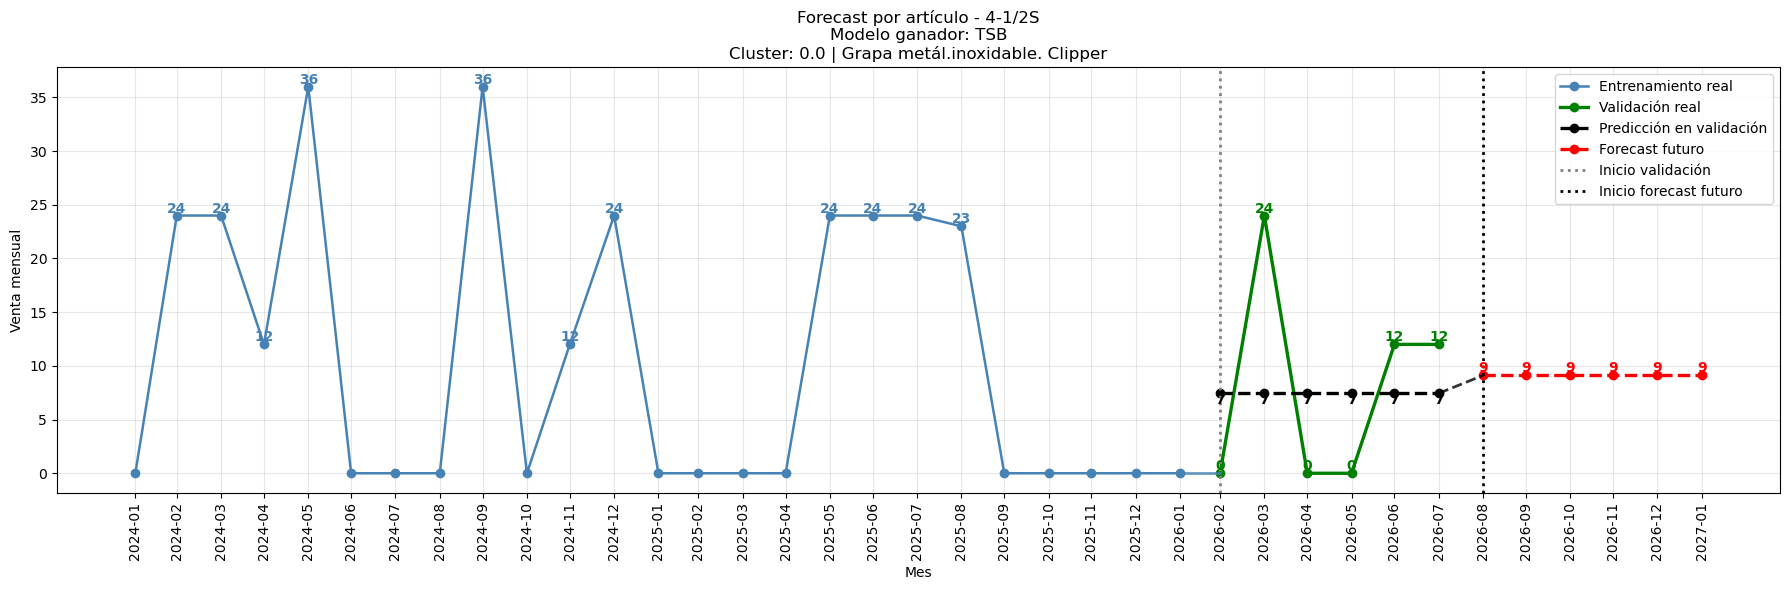

In [468]:
graficar_forecast_articulo(
    df_forecast_visual=df_forecast_visual,
    unique_id="4-1/2S",
    info_split=info_split,
    metadata_por_articulo=metadata_por_articulo,
    mostrar_etiquetas=True
)

In [476]:
df_forecast_visual.head(100)

,unique_id,ds,periodo,best_model,y_real,y_pred
0,0225-3M,2024-01-31,Entrenamiento,Dummy_promedio_24m,0.0,NaN
1,0225-3M,2024-02-29,Entrenamiento,Dummy_promedio_24m,0.0,NaN
2,0225-3M,2024-03-31,Entrenamiento,Dummy_promedio_24m,0.0,NaN
3,0225-3M,2024-04-30,Entrenamiento,Dummy_promedio_24m,0.0,NaN
4,0225-3M,2024-05-31,Entrenamiento,Dummy_promedio_24m,0.0,NaN
...,...,...,...,...,...,...
95,0384-3M-JASON,2025-10-31,Entrenamiento,CrostonClassic,15.0,NaN
96,0384-3M-JASON,2025-11-30,Entrenamiento,CrostonClassic,30.0,NaN
97,0384-3M-JASON,2025-12-31,Entrenamiento,CrostonClassic,55.0,NaN
98,0384-3M-JASON,2026-01-31,Entrenamiento,CrostonClassic,45.0,NaN


In [470]:
df.head()

,unique_id,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,cluster_kmeans_final,descripcion_cluster,...,venta_2025_10,venta_2025_11,venta_2025_12,venta_2026_01,venta_2026_02,venta_2026_03,venta_2026_04,venta_2026_05,venta_2026_06,venta_2026_07
0,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",...,6.0,12.0,0.0,0.0,24.0,0.0,0.0,24.0,9.0,0.0
1,0270H,"Manga de sincronismo, 270H, longitud externa 2...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,2.0,Demanda activa y reciente con señales de creci...,...,50.0,600.0,225.0,150.0,38.0,200.0,19.0,0.0,300.0,350.0
2,0384-3M-JASON,"Manga de sincronismo, 384-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,15.0,30.0,55.0,45.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0390H-JASON,"Manga de sincronismo, 390H, longitud externa 3...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,JASON,MM,2.0,Demanda activa y reciente con señales de creci...,...,0.0,0.0,0.0,0.0,25.0,0.0,201.0,25.0,140.0,0.0
4,0420H,"Manga de sincronismo, 420H, longitud externa 4...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,38.0,0.0,0.0,50.0,0.0,0.0,19.0,0.0,0.0,0.0


In [473]:
# ============================================================
# Agregar forecast futuro a todos los artículos
# ============================================================

def agregar_forecast_todos_los_articulos(
    df,
    df_forecast,
    columna_codigo_df="unique_id",
    columna_id_forecast="unique_id",
    columna_fecha="ds",
    columna_prediccion="y_pred",
    columna_periodo="periodo",
    valor_periodo_forecast="Forecast futuro",
    prefijo_forecast="forecast",
    redondeo=None
):
    """
    Agrega las predicciones futuras de todos los artículos al dataframe original.

    Entrada:
    - df: dataframe consolidado, una fila por artículo.
    - df_forecast: dataframe de forecast en formato largo:
        unique_id | ds | y_pred

      También puede venir de df_forecast_visual, en cuyo caso se filtra:
        periodo == "Forecast futuro"

    Salida:
    - df_resultado: dataframe original + columnas forecast_YYYY_MM + compra_sugerida
    - df_forecast_wide: matriz de forecast futuro por artículo
    - columnas_forecast: lista de columnas forecast creadas
    """

    import pandas as pd
    import numpy as np

    df_base = df.copy()
    df_pred = df_forecast_visual[df_forecast_visual["periodo"] == "Forecast futuro"].copy()

    # ------------------------------------------------------------
    # Asegurar que el código del artículo esté como columna
    # ------------------------------------------------------------

    if columna_codigo_df not in df_base.columns:
        if df_base.index.name == columna_codigo_df:
            df_base = df_base.reset_index()
        else:
            raise ValueError(
                f"No se encontró la columna {columna_codigo_df} en df."
            )

    # ------------------------------------------------------------
    # Si viene df_forecast_visual, filtrar solo Forecast futuro
    # ------------------------------------------------------------

    if columna_periodo in df_pred.columns:
        df_pred = df_pred[
            df_pred[columna_periodo] == valor_periodo_forecast
        ].copy()

    # ------------------------------------------------------------
    # Validar columnas requeridas
    # ------------------------------------------------------------

    columnas_requeridas = {
        columna_id_forecast,
        columna_fecha,
        columna_prediccion
    }

    faltantes = columnas_requeridas - set(df_pred.columns)

    if faltantes:
        raise ValueError(
            f"Faltan columnas requeridas en df_forecast: {faltantes}"
        )

    # ------------------------------------------------------------
    # Asegurar tipos
    # ------------------------------------------------------------

    df_pred[columna_fecha] = pd.to_datetime(df_pred[columna_fecha])

    df_pred[columna_prediccion] = pd.to_numeric(
        df_pred[columna_prediccion],
        errors="coerce"
    ).fillna(0)

    df_pred[columna_prediccion] = df_pred[columna_prediccion].clip(lower=0)

    # ------------------------------------------------------------
    # Redondeo operativo
    # ------------------------------------------------------------

    if redondeo == "ceil":
        df_pred[columna_prediccion] = (
            np.ceil(df_pred[columna_prediccion])
            .astype(int)
        )

    elif redondeo == "round":
        df_pred[columna_prediccion] = (
            df_pred[columna_prediccion]
            .round(0)
            .astype(int)
        )

    # ------------------------------------------------------------
    # Crear nombres de columnas forecast_YYYY_MM
    # ------------------------------------------------------------

    df_pred["columna_forecast"] = df_pred[columna_fecha].apply(
        lambda fecha: f"{prefijo_forecast}_{fecha.year}_{fecha.month:02d}"
    )

    # ------------------------------------------------------------
    # Convertir forecast largo a matriz ancha
    # ------------------------------------------------------------

    df_forecast_wide = (
        df_pred
        .pivot_table(
            index=columna_id_forecast,
            columns="columna_forecast",
            values=columna_prediccion,
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    # ------------------------------------------------------------
    # Ordenar columnas forecast cronológicamente
    # ------------------------------------------------------------

    columnas_forecast = [
        col for col in df_forecast_wide.columns
        if col.startswith(prefijo_forecast + "_")
    ]

    columnas_forecast = sorted(
        columnas_forecast,
        key=lambda col: pd.to_datetime(
            col.replace(prefijo_forecast + "_", ""),
            format="%Y_%m"
        )
    )

    df_forecast_wide = df_forecast_wide[
        [columna_id_forecast] + columnas_forecast
    ]

    # ------------------------------------------------------------
    # Compra sugerida = suma total del forecast futuro
    # ------------------------------------------------------------

    df_forecast_wide["compra_sugerida"] = (
        df_forecast_wide[columnas_forecast]
        .sum(axis=1)
    )

    # ------------------------------------------------------------
    # Merge contra todos los artículos del dataframe original
    # ------------------------------------------------------------

    df_resultado = df_base.merge(
        df_forecast_wide,
        left_on=columna_codigo_df,
        right_on=columna_id_forecast,
        how="left",
        validate="one_to_one"
    )

    # Eliminar columna duplicada si se llama diferente
    if columna_codigo_df != columna_id_forecast:
        df_resultado = df_resultado.drop(
            columns=[columna_id_forecast]
        )

    # ------------------------------------------------------------
    # Rellenar artículos sin forecast con cero
    # ------------------------------------------------------------

    columnas_nuevas = columnas_forecast + ["compra_sugerida"]

    df_resultado[columnas_nuevas] = (
        df_resultado[columnas_nuevas]
        .fillna(0)
    )

    if redondeo in ["ceil", "round"]:
        df_resultado[columnas_nuevas] = (
            df_resultado[columnas_nuevas]
            .astype(int)
        )

    return df_resultado, df_forecast_wide, columnas_forecast

In [477]:
df_con_forecast, df_forecast_wide, columnas_forecast = agregar_forecast_todos_los_articulos(
    df=df,
    df_forecast=df_forecast_visual,
    columna_codigo_df="unique_id",
    columna_id_forecast="unique_id",
    columna_fecha="ds",
    columna_prediccion="y_pred",
    columna_periodo="periodo",
    valor_periodo_forecast="Forecast futuro",
    redondeo="round"
)

In [501]:
df_forecast_wide

columna_forecast,unique_id,forecast_2026_08,forecast_2026_09,forecast_2026_10,forecast_2026_11,forecast_2026_12,forecast_2027_01,compra_sugerida
0,0225-3M,11,11,11,11,11,11,66
1,0270H,175,175,175,175,175,175,1050
2,0384-3M-JASON,7,7,7,7,7,7,42
3,0390H-JASON,32,32,32,32,32,32,192
4,0420H,8,8,8,8,8,8,48
...,...,...,...,...,...,...,...,...
445,W16H6,297,297,297,297,297,297,1782
446,W25H6,251,251,251,251,251,251,1506
447,W30H6,234,234,234,234,234,234,1404
448,W8,174854,174854,174854,174854,174854,174854,1049124


In [478]:
df_con_forecast.head()

,unique_id,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,cluster_kmeans_final,descripcion_cluster,...,venta_2026_05,venta_2026_06,venta_2026_07,forecast_2026_08,forecast_2026_09,forecast_2026_10,forecast_2026_11,forecast_2026_12,forecast_2027_01,compra_sugerida
0,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",...,24.0,9.0,0.0,11,11,11,11,11,11,66
1,0270H,"Manga de sincronismo, 270H, longitud externa 2...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,2.0,Demanda activa y reciente con señales de creci...,...,0.0,300.0,350.0,175,175,175,175,175,175,1050
2,0384-3M-JASON,"Manga de sincronismo, 384-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,0.0,0.0,0.0,7,7,7,7,7,7,42
3,0390H-JASON,"Manga de sincronismo, 390H, longitud externa 3...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,JASON,MM,2.0,Demanda activa y reciente con señales de creci...,...,25.0,140.0,0.0,32,32,32,32,32,32,192
4,0420H,"Manga de sincronismo, 420H, longitud externa 4...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,0.0,0.0,0.0,8,8,8,8,8,8,48


In [479]:
# ============================================================
# 43. Exportar matriz mensual a Excel
# ============================================================

ruta_excel= "./Datos/df_matriz_venta_con_forecas_&_compra_sugerida.xlsx"

with pd.ExcelWriter(ruta_excel, engine="openpyxl") as writer:
    
    df_con_forecast.to_excel(
        writer,
        sheet_name="matriz_ventas_&_forecast",
        index=False
    )
    

print(f"Archivo exportado correctamente en: {ruta_excel}")

Archivo exportado correctamente en: ./Datos/df_matriz_venta_con_forecas_&_compra_sugerida.xlsx
